# Análise e Previsão da Potência Gerada por Turbina Eólica: Um Estudo Comparativo de Modelos Preditivos

## Introdução

Este notebook apresenta um experimento acadêmico focado na previsão da potência gerada por turbinas eólicas. Serão exploradas diferentes metodologias de modelagem, desde baselines simples até modelos de aprendizado de máquina avançados e redes neurais recorrentes, visando identificar o modelo com melhor desempenho para horizontes de previsão de até 6 horas.

In [ ]:
!pip install lightgbm optuna scikit-posthocs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.0 MB/s eta 0:00:00


## 1. Configuração Inicial

Esta seção prepara o ambiente, instalando as bibliotecas necessárias e configurando parâmetros globais para garantir a reprodutibilidade do experimento.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.multioutput import MultiOutputRegressor

from lightgbm import LGBMRegressor

from scipy.stats import friedmanchisquare

import scikit_posthocs as sp

In [ ]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 2. Carregamento e Exploração Inicial dos Dados

Nesta etapa, os dados da potência gerada e variáveis meteorológicas são carregados e uma análise exploratória inicial é realizada para entender sua estrutura, identificar padrões e detectar a presença de valores ausentes (gaps).

In [ ]:
TARGET = "potencia_gerada"

FORECAST_STEPS = [
    4,   # 1h
    8,   # 2h
    12,  # 3h
    16,  # 4h
    20,  # 5h
    24   # 6h
]

LAG_OPTIONS = [
    8,   # 2h
    16,  # 4h
    24   # 6h
]

N_SPLITS = 5

In [ ]:
df = pd.read_excel(
    "df_tratado.xlsx"
)

df.head()

,timestamp,data,hora_local,potencia_gerada,vento_velocidade,temp_inst,humidade_inst,ponto_orvalho_celsius,pressao_inst,vento_direcao,precipitacao
0,2023-01-04 11:00:00,2023-01-04,11:00:07,169.70,6.2,31.3,60.0,26.3,1009.1,354.0,0.0
1,2023-01-04 11:15:00,2023-01-04,11:15:07,313.82,7.4,31.3,59.0,26.4,1009.1,4.0,0.0
2,2023-01-04 11:30:00,2023-01-04,11:30:07,272.84,7.1,31.6,59.0,26.4,1008.9,5.0,0.0
3,2023-01-04 11:45:00,2023-01-04,11:45:07,327.94,7.5,31.7,58.0,26.5,1008.8,3.0,0.0
4,2023-01-04 12:00:00,2023-01-04,12:00:07,179.56,6.3,31.3,61.0,26.6,1008.6,12.0,0.0


In [ ]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df = df.sort_values(
    "timestamp"
)

df = df.set_index(
    "timestamp"
)

df.head()

,data,hora_local,potencia_gerada,vento_velocidade,temp_inst,humidade_inst,ponto_orvalho_celsius,pressao_inst,vento_direcao,precipitacao
timestamp,,,,,,,,,,
2023-01-04 11:00:00,2023-01-04,11:00:07,169.70,6.2,31.3,60.0,26.3,1009.1,354.0,0.0
2023-01-04 11:15:00,2023-01-04,11:15:07,313.82,7.4,31.3,59.0,26.4,1009.1,4.0,0.0
2023-01-04 11:30:00,2023-01-04,11:30:07,272.84,7.1,31.6,59.0,26.4,1008.9,5.0,0.0
2023-01-04 11:45:00,2023-01-04,11:45:07,327.94,7.5,31.7,58.0,26.5,1008.8,3.0,0.0
2023-01-04 12:00:00,2023-01-04,12:00:07,179.56,6.3,31.3,61.0,26.6,1008.6,12.0,0.0


In [ ]:
TARGET = "potencia_gerada"

df_gap = df.copy()

df_gap["is_gap"] = (
    df_gap[TARGET].isna()
).astype(int)

print(
    f"Total de registros: {len(df_gap):,}"
)

print(
    f"Registros com gap: {df_gap['is_gap'].sum():,}"
)

print(
    f"% faltante: {100*df_gap['is_gap'].mean():.2f}%"
)

Total de registros: 90,676
Registros com gap: 16,244
% faltante: 17.91%


In [ ]:
df_gap["gap_group"] = (
    df_gap["is_gap"]
      .ne(df_gap["is_gap"].shift())
      .cumsum()
)

gap_sizes = (

    df_gap[df_gap["is_gap"] == 1]

    .groupby("gap_group")

    .size()

    .reset_index(name="gap_size")

)

gap_sizes.head()

,gap_group,gap_size
0,2,12
1,4,48
2,6,713
3,8,12
4,10,1


In [ ]:
gap_sizes["gap_minutes"] = (
    gap_sizes["gap_size"] * 15
)

gap_sizes["gap_hours"] = (
    gap_sizes["gap_minutes"] / 60
)

gap_sizes.describe()

,gap_group,gap_size,gap_minutes,gap_hours
count,70.00000,70.000000,70.000000,70.000000
mean,71.00000,232.057143,3480.857143,58.014286
std,40.70217,921.367617,13820.514262,230.341904
min,2.00000,1.000000,15.000000,0.250000
25%,36.50000,4.000000,60.000000,1.000000
50%,71.00000,4.000000,60.000000,1.000000
75%,105.50000,12.000000,180.000000,3.000000
max,140.00000,5628.000000,84420.000000,1407.000000


In [ ]:
gap_sizes.sort_values(
    "gap_hours",
    ascending=False
).head(20)

,gap_group,gap_size,gap_minutes,gap_hours
57,116,5628,84420,1407.00
64,130,4075,61125,1018.75
11,24,2868,43020,717.00
60,122,2304,34560,576.00
2,6,713,10695,178.25
67,136,96,1440,24.00
61,124,58,870,14.50
1,4,48,720,12.00
66,134,47,705,11.75
54,110,38,570,9.50


### 2.2 Distribuição dos Tamanhos dos Gaps

Aqui, é apresentada a distribuição dos tamanhos dos gaps encontrados, permitindo uma visualização clara da frequência e magnitude das interrupções nos dados.

### 2.3 Tabela Resumo dos Gaps

Uma tabela resumo é criada para categorizar os gaps por tamanho e apresentar estatísticas como quantidade, média e máximo de registros por categoria.

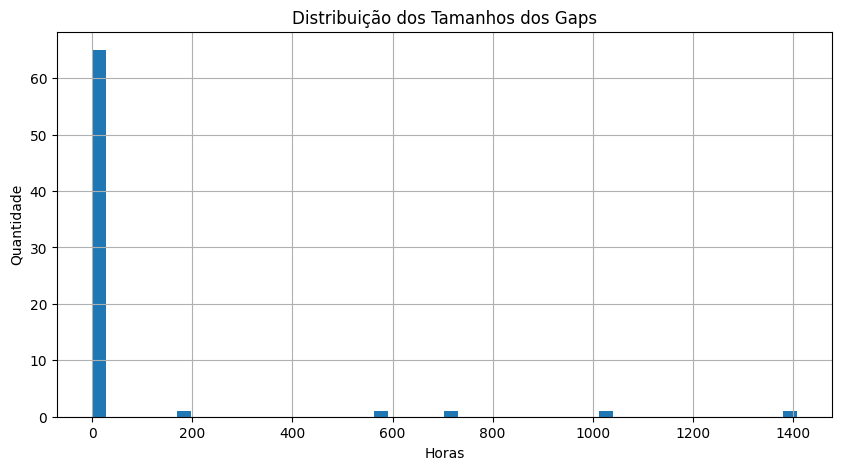

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

gap_sizes["gap_hours"].hist(
    bins=50
)

plt.xlabel("Horas")

plt.ylabel("Quantidade")

plt.title(
    "Distribuição dos Tamanhos dos Gaps"
)

plt.show()

### 2.1 Análise de Gaps nos Dados

Esta subseção detalha a metodologia de identificação e quantificação dos gaps presentes na série temporal, essencial para o tratamento de dados faltantes.

In [ ]:
def classify_gap(size):

    if size <= 4:
        return "Até 1h"

    elif size <= 24:
        return "1h-6h"

    elif size <= 96:
        return "6h-24h"

    else:
        return ">24h"

In [ ]:
gap_sizes["categoria"] = (
    gap_sizes["gap_size"]
      .apply(classify_gap)
)

gap_sizes["categoria"].value_counts()

,count
categoria,
Até 1h,41
1h-6h,18
6h-24h,6
>24h,5


In [ ]:
gap_table = (

    gap_sizes

    .groupby("categoria")

    .agg(
        quantidade=("gap_size","count"),
        media_registros=("gap_size","mean"),
        max_registros=("gap_size","max")
    )

)

gap_table

,quantidade,media_registros,max_registros
categoria,,,
1h-6h,18,11.333333,24
6h-24h,6,52.000000,96
>24h,5,3117.600000,5628
Até 1h,41,3.414634,4


In [ ]:
gap_table.reset_index()

,categoria,quantidade,media_registros,max_registros
0,1h-6h,18,11.333333,24
1,6h-24h,6,52.000000,96
2,>24h,5,3117.600000,5628
3,Até 1h,41,3.414634,4


### 2.4 Ocorrência Temporal dos Gaps

Este gráfico visualiza a distribuição temporal dos gaps, indicando os períodos em que as interrupções nos dados são mais frequentes.

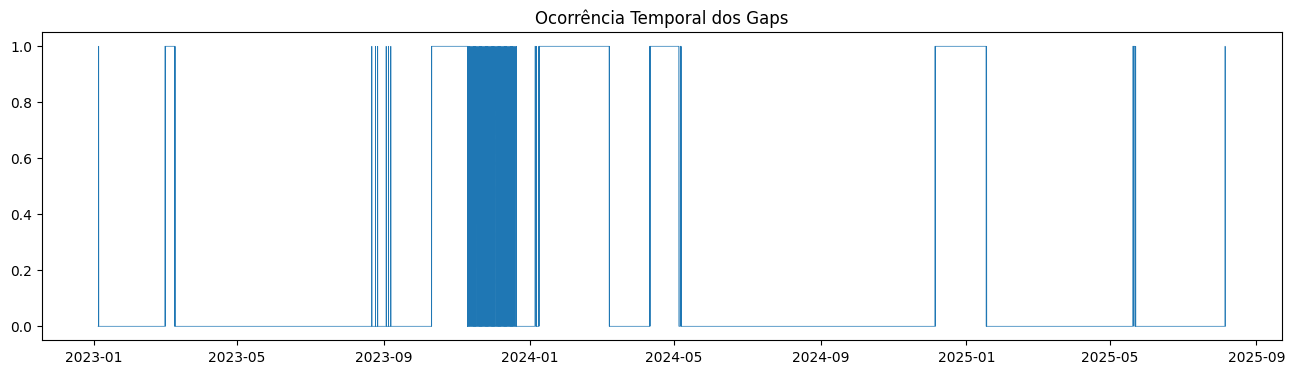

In [ ]:
plt.figure(figsize=(16,4))

plt.plot(
    df_gap.index,
    df_gap["is_gap"],
    linewidth=0.5
)

plt.title(
    "Ocorrência Temporal dos Gaps"
)

plt.show()

In [ ]:
missing_table = (

    df.isna()

    .mean()

    .mul(100)

    .sort_values(
        ascending=False
    )

    .to_frame(
        "percentual_missing"
    )

)

missing_table

,percentual_missing
data,17.914332
hora_local,17.914332
potencia_gerada,17.914332
vento_velocidade,17.914332
temp_inst,17.914332
humidade_inst,17.914332
ponto_orvalho_celsius,17.914332
pressao_inst,17.914332
vento_direcao,17.914332
precipitacao,17.914332


### 2.5 Informações Detalhadas dos Gaps

Nesta seção, são extraídas informações mais detalhadas sobre os gaps, incluindo suas datas de início e fim, duração em registros e dias.

In [ ]:
gap_info = []

for gid in gap_sizes["gap_group"]:

    tmp = df_gap[df_gap["gap_group"] == gid]

    gap_info.append({
        "gap_group": gid,
        "inicio": tmp.index.min(),
        "fim": tmp.index.max(),
        "registros": len(tmp),
        "dias": len(tmp)*15/60/24
    })

gap_info = pd.DataFrame(gap_info)

gap_info.sort_values(
    "dias",
    ascending=False
).head(10)

,gap_group,inicio,fim,registros,dias
57,116,2024-01-09 00:00:00,2024-03-07 14:45:00,5628,58.625000
64,130,2024-12-06 00:00:00,2025-01-17 10:30:00,4075,42.447917
11,24,2023-10-11 00:00:00,2023-11-09 20:45:00,2868,29.875000
60,122,2024-04-11 00:00:00,2024-05-04 23:45:00,2304,24.000000
2,6,2023-03-02 00:00:00,2023-03-09 10:00:00,713,7.427083
67,136,2025-05-21 00:00:00,2025-05-21 23:45:00,96,1.000000
61,124,2024-05-06 00:00:00,2024-05-06 14:15:00,58,0.604167
1,4,2023-03-01 09:00:00,2023-03-01 20:45:00,48,0.500000
66,134,2025-05-20 09:15:00,2025-05-20 20:45:00,47,0.489583
54,110,2024-01-05 11:30:00,2024-01-05 20:45:00,38,0.395833


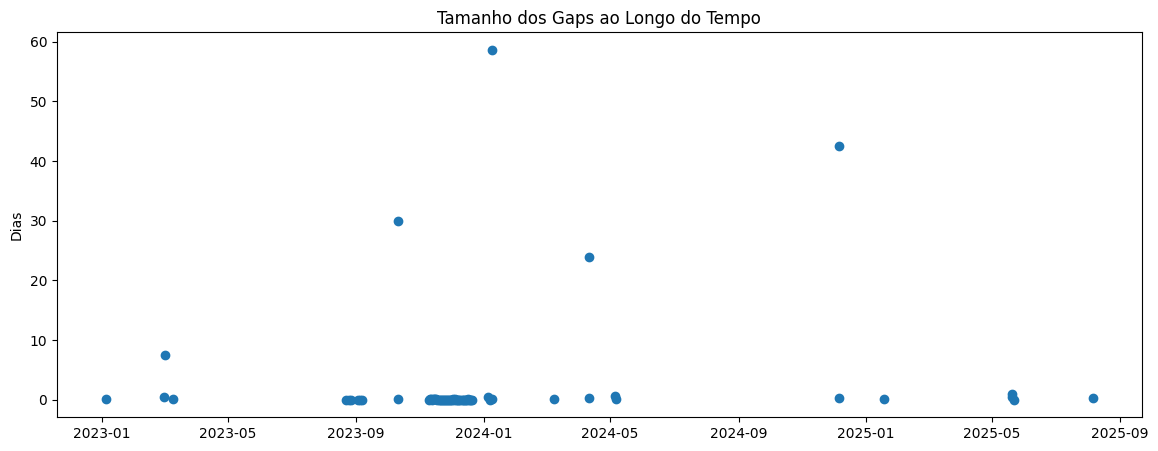

In [ ]:
plt.figure(figsize=(14,5))

plt.scatter(
    gap_info["inicio"],
    gap_info["dias"]
)

plt.ylabel("Dias")

plt.title(
    "Tamanho dos Gaps ao Longo do Tempo"
)

plt.show()

### 2.6 Visualização Temporal dos Gaps

Um gráfico de dispersão é utilizado para visualizar a duração dos gaps ao longo do tempo, auxiliando na identificação de padrões ou tendências.

In [ ]:
TARGET_BENCH = "potencia_gerada"

In [ ]:
series_clean = (

    df[TARGET_BENCH]

    .dropna()

)

In [ ]:
def create_artificial_gap(
    series,
    gap_size,
    seed=42
):

    rng = np.random.default_rng(seed)

    start = rng.integers(
        100,
        len(series)-gap_size-100
    )

    original = series.copy()

    masked = series.copy()

    mask = np.zeros(
        len(series),
        dtype=bool
    )

    mask[start:start+gap_size] = True

    masked.iloc[
        start:start+gap_size
    ] = np.nan

    return original, masked, mask

In [ ]:
def impute_time(masked):

    return masked.interpolate(
        method="time"
    )

In [ ]:
def impute_ffill(masked):

    return masked.ffill()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def evaluate_imputation(
    original,
    imputed,
    mask
):

    y_true = original[mask]

    y_pred = imputed[mask]

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    return mae, rmse

In [ ]:
results = []

for gap_size in [
    1,
    2,
    4,
    8,
    24,
    96
]:

    original, masked, mask = create_artificial_gap(
        series_clean,
        gap_size
    )

    gap_mask = masked.isna()

    # interpolação

    imp = impute_time(masked)

    mae, rmse = evaluate_imputation(
        original,
        imp,
        gap_mask
    )

    results.append({
        "metodo":"time",
        "gap_size":gap_size,
        "MAE":mae,
        "RMSE":rmse
    })

    # ffill

    imp = impute_ffill(masked)

    mae, rmse = evaluate_imputation(
        original,
        imp,
        gap_mask
    )

    results.append({
        "metodo":"ffill",
        "gap_size":gap_size,
        "MAE":mae,
        "RMSE":rmse
    })

results_df = pd.DataFrame(results)

results_df

,metodo,gap_size,MAE,RMSE
0,time,1,0.000000,0.000000
1,ffill,1,0.000000,0.000000
2,time,2,0.000000,0.000000
3,ffill,2,0.000000,0.000000
4,time,4,0.000000,0.000000
5,ffill,4,0.000000,0.000000
6,time,8,0.000000,0.000000
7,ffill,8,0.000000,0.000000
8,time,24,0.000000,0.000000
9,ffill,24,0.000000,0.000000


In [ ]:
gap_info.sort_values(
    "dias",
    ascending=False
).head(20)

,gap_group,inicio,fim,registros,dias
57,116,2024-01-09 00:00:00,2024-03-07 14:45:00,5628,58.625000
64,130,2024-12-06 00:00:00,2025-01-17 10:30:00,4075,42.447917
11,24,2023-10-11 00:00:00,2023-11-09 20:45:00,2868,29.875000
60,122,2024-04-11 00:00:00,2024-05-04 23:45:00,2304,24.000000
2,6,2023-03-02 00:00:00,2023-03-09 10:00:00,713,7.427083
67,136,2025-05-21 00:00:00,2025-05-21 23:45:00,96,1.000000
61,124,2024-05-06 00:00:00,2024-05-06 14:15:00,58,0.604167
1,4,2023-03-01 09:00:00,2023-03-01 20:45:00,48,0.500000
66,134,2025-05-20 09:15:00,2025-05-20 20:45:00,47,0.489583
54,110,2024-01-05 11:30:00,2024-01-05 20:45:00,38,0.395833


Quantos blocos contínuos de dados realmente temos?

Porque o que interessa para modelos temporais não é apenas a quantidade de linhas.

É a quantidade de sequência contínua.

## Criar os blocos contínuos

### 3.1 Criação de Blocos Contínuos

Gaps muito grandes podem quebrar a continuidade temporal. Esta subseção define uma estratégia para segmentar a série temporal em blocos contínuos, desconsiderando gaps prolongados.

### 3.2 Sumário dos Blocos Válidos

Após a criação dos blocos, esta seção sumariza os blocos considerados válidos para a modelagem, com base em critérios de duração mínima.

In [ ]:
MAX_IMPUTABLE_GAP = 96 # 24h Tudo acima disso será considerado quebra da série.

In [ ]:
large_gaps = gap_info[
    gap_info["registros"] > MAX_IMPUTABLE_GAP
].copy()

large_gaps

,gap_group,inicio,fim,registros,dias
2,6,2023-03-02,2023-03-09 10:00:00,713,7.427083
11,24,2023-10-11,2023-11-09 20:45:00,2868,29.875000
57,116,2024-01-09,2024-03-07 14:45:00,5628,58.625000
60,122,2024-04-11,2024-05-04 23:45:00,2304,24.000000
64,130,2024-12-06,2025-01-17 10:30:00,4075,42.447917


In [ ]:
df_blocks = df.copy()

df_blocks["block_id"] = 1

In [ ]:
for _, row in large_gaps.iterrows(): # marcar as quebras

    fim_gap = row["fim"]

    df_blocks.loc[
        df_blocks.index > fim_gap,
        "block_id"
    ] += 1

In [ ]:
df_blocks["block_id"].value_counts().sort_index()

,count
block_id,
1,6141
2,23563
3,11400
4,5604
5,24715
6,19253


In [ ]:
block_summary = []

for block in sorted(
    df_blocks["block_id"].unique()
):

    tmp = df_blocks[
        df_blocks["block_id"] == block
    ]

    duration_days = (
        tmp.index.max() -
        tmp.index.min()
    ).days

    block_summary.append({

        "block_id": block,

        "inicio": tmp.index.min(),

        "fim": tmp.index.max(),

        "registros": len(tmp),

        "dias": duration_days

    })

block_summary = pd.DataFrame(
    block_summary
)

block_summary

,block_id,inicio,fim,registros,dias
0,1,2023-01-04 11:00:00,2023-03-09 10:00:00,6141,63
1,2,2023-03-09 10:15:00,2023-11-09 20:45:00,23563,245
2,3,2023-11-09 21:00:00,2024-03-07 14:45:00,11400,118
3,4,2024-03-07 15:00:00,2024-05-04 23:45:00,5604,58
4,5,2024-05-05 00:00:00,2025-01-17 10:30:00,24715,257
5,6,2025-01-17 10:45:00,2025-08-05 23:45:00,19253,200


Existem blocos muito pequenos?

In [ ]:
MIN_BLOCK_DAYS = 30

In [ ]:
valid_blocks = block_summary[
    block_summary["dias"] >= 30
]

valid_blocks

,block_id,inicio,fim,registros,dias
0,1,2023-01-04 11:00:00,2023-03-09 10:00:00,6141,63
1,2,2023-03-09 10:15:00,2023-11-09 20:45:00,23563,245
2,3,2023-11-09 21:00:00,2024-03-07 14:45:00,11400,118
3,4,2024-03-07 15:00:00,2024-05-04 23:45:00,5604,58
4,5,2024-05-05 00:00:00,2025-01-17 10:30:00,24715,257
5,6,2025-01-17 10:45:00,2025-08-05 23:45:00,19253,200


In [ ]:
valid_ids = valid_blocks[
    "block_id"
].tolist()

df_model = df_blocks[
    df_blocks["block_id"].isin(
        valid_ids
    )
].copy()

In [ ]:
block_summary

,block_id,inicio,fim,registros,dias
0,1,2023-01-04 11:00:00,2023-03-09 10:00:00,6141,63
1,2,2023-03-09 10:15:00,2023-11-09 20:45:00,23563,245
2,3,2023-11-09 21:00:00,2024-03-07 14:45:00,11400,118
3,4,2024-03-07 15:00:00,2024-05-04 23:45:00,5604,58
4,5,2024-05-05 00:00:00,2025-01-17 10:30:00,24715,257
5,6,2025-01-17 10:45:00,2025-08-05 23:45:00,19253,200


### 3.3 Análise de Missing Values Pós-Blocos

Verifica-se a presença de valores ausentes após a segmentação em blocos e a filtragem, garantindo que apenas dados de alta qualidade sejam utilizados na modelagem.

In [ ]:
df_blocks["block_id"].value_counts()

,count
block_id,
5,24715
2,23563
6,19253
3,11400
1,6141
4,5604


Foram identificadas interrupções prolongadas de aquisição superiores a 24 horas. Em vez de realizar imputação desses períodos, os dados foram segmentados em blocos temporais contínuos. Essa estratégia preserva a estrutura cronológica da série e evita a introdução de informações artificiais em intervalos extensos sem observação.

In [ ]:
missing_table = (

    df_model
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_table.head(30)

,0
data,16244
hora_local,16244
potencia_gerada,16244
vento_velocidade,16244
temp_inst,16244
humidade_inst,16244
ponto_orvalho_celsius,16244
pressao_inst,16244
vento_direcao,16244
precipitacao,16244


In [ ]:
missing_pct = (

    df_model
    .isna()
    .mean()
    .mul(100)
    .sort_values(
        ascending=False
    )
)

missing_pct.head(30)

,0
data,17.914332
hora_local,17.914332
potencia_gerada,17.914332
vento_velocidade,17.914332
temp_inst,17.914332
humidade_inst,17.914332
ponto_orvalho_celsius,17.914332
pressao_inst,17.914332
vento_direcao,17.914332
precipitacao,17.914332


Quanto dos 17,9% de missing pertence aos gaps gigantes?

### 3.4 Imputação de Gaps Curtos

Os gaps menores que um limite predefinido são imputados usando interpolação temporal, preenchendo as lacunas na série de dados de forma consistente.

In [ ]:
large_gap_records = gap_info[
    gap_info["registros"] > 96
]["registros"].sum()

large_gap_records

np.int64(15588)

In [ ]:
total_missing = 16244

print(
    large_gap_records /
    total_missing * 100
)

95.96158581630141


## Objetivo:

Dataset bruto
    ↓
Remover blocos irrecuperáveis
    ↓
Imputar gaps curtos
    ↓
Criar features temporais
    ↓
Criar cenários
    ↓
Dataset pronto para modelagem





## 3. Pré-processamento e Engenharia de Features

Esta seção descreve as etapas de pré-processamento dos dados, incluindo o tratamento de gaps, a criação de blocos contínuos e a engenharia de features temporais, preparando o dataset para a modelagem.

In [ ]:
df_model

,data,hora_local,potencia_gerada,vento_velocidade,temp_inst,humidade_inst,ponto_orvalho_celsius,pressao_inst,vento_direcao,precipitacao,block_id
timestamp,,,,,,,,,,,
2023-01-04 11:00:00,2023-01-04,11:00:07,169.70,6.2,31.3,60.0,26.3,1009.1,354.0,0.0,1
2023-01-04 11:15:00,2023-01-04,11:15:07,313.82,7.4,31.3,59.0,26.4,1009.1,4.0,0.0,1
2023-01-04 11:30:00,2023-01-04,11:30:07,272.84,7.1,31.6,59.0,26.4,1008.9,5.0,0.0,1
2023-01-04 11:45:00,2023-01-04,11:45:07,327.94,7.5,31.7,58.0,26.5,1008.8,3.0,0.0,1
2023-01-04 12:00:00,2023-01-04,12:00:07,179.56,6.3,31.3,61.0,26.6,1008.6,12.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
2025-08-05 22:45:00,2025-08-05,22:45:07,0.00,0.9,20.0,88.0,22.9,1019.8,337.0,0.0,6
2025-08-05 23:00:00,2025-08-05,23:00:07,0.00,0.8,19.8,88.0,22.9,1019.7,333.0,0.0,6
2025-08-05 23:15:00,2025-08-05,23:15:07,0.00,0.7,19.9,87.0,22.9,1019.7,340.0,0.0,6


In [ ]:
df_final = df_model.copy() # contem apenas blocos validos

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90676 entries, 2023-01-04 11:00:00 to 2025-08-05 23:45:00
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   data                   74432 non-null  datetime64[ns]
 1   hora_local             74432 non-null  object        
 2   potencia_gerada        74432 non-null  float64       
 3   vento_velocidade       74432 non-null  float64       
 4   temp_inst              74432 non-null  float64       
 5   humidade_inst          74432 non-null  float64       
 6   ponto_orvalho_celsius  74432 non-null  float64       
 7   pressao_inst           74432 non-null  float64       
 8   vento_direcao          74432 non-null  float64       
 9   precipitacao           74432 non-null  float64       
 10  block_id               90676 non-null  int64         
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 8.3+ MB


Como os gaps curtos representam apenas 4% dos missing:

In [ ]:
cols_to_impute = [
    'potencia_gerada', 'vento_velocidade', 'temp_inst',
    'humidade_inst', 'ponto_orvalho_celsius', 'pressao_inst',
    'vento_direcao', 'precipitacao'
]

# Imputação temporal apenas nas colunas numéricas
df_final[cols_to_impute] = df_final[cols_to_impute].interpolate(method='time')

# Preencher colunas categóricas/auxiliares remanescentes se necessário
df_final['hora_local'] = df_final['hora_local'].ffill()
df_final['data'] = df_final['data'].ffill()

print(f"Missing values after fix:\n{df_final[cols_to_impute].isna().sum()}")

Missing values after fix:
potencia_gerada          0
vento_velocidade         0
temp_inst                0
humidade_inst            0
ponto_orvalho_celsius    0
pressao_inst             0
vento_direcao            0
precipitacao             0
dtype: int64


In [ ]:
missing_after = (
    df_final.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_after.head(20)

,0
data,0
hora_local,0
potencia_gerada,0
vento_velocidade,0
temp_inst,0
humidade_inst,0
ponto_orvalho_celsius,0
pressao_inst,0
vento_direcao,0
precipitacao,0


Garantir preenchimento das bordas

Às vezes sobra alguma borda...

In [ ]:
df_final = df_final.ffill()
df_final = df_final.bfill()

In [ ]:
df_final.isna().sum().sum()

np.int64(0)

# Feature Engineering Temporal

### 3.5 Engenharia de Features Temporais

São criadas novas features a partir da coluna de tempo, como hora, dia da semana e mês, para capturar padrões sazonais e cíclicos nos dados.

In [ ]:
df_final["hora"] = df_final.index.hour

df_final["dia_semana"] = (
    df_final.index.dayofweek
)

df_final["mes"] = (
    df_final.index.month
)

Features Cíclicas

Essas costumam ajudar bastante LightGBM.

### 3.6 Features Cíclicas

Para modelos que se beneficiam de representações cíclicas, as features temporais são transformadas usando funções seno e cosseno.

In [ ]:
import numpy as np

In [ ]:
df_final["hora_sin"] = np.sin(
    2*np.pi*df_final["hora"]/24
)

df_final["hora_cos"] = np.cos(
    2*np.pi*df_final["hora"]/24
)

df_final["dia_sin"] = np.sin(
    2*np.pi*df_final["dia_semana"]/7
)

df_final["dia_cos"] = np.cos(
    2*np.pi*df_final["dia_semana"]/7
)

df_final["mes_sin"] = np.sin(
    2*np.pi*df_final["mes"]/12
)

df_final["mes_cos"] = np.cos(
    2*np.pi*df_final["mes"]/12
)

## Acima do cutin

### 3.7 Feature 'Acima do Cut-in'

Criação de uma feature binária que indica se a velocidade do vento está acima do ponto de corte (cut-in) da turbina, influenciando diretamente a geração de potência.

In [ ]:
df_final["above_cutin"] = (
    df_final["vento_velocidade"] > 3.6
).astype(int)

In [ ]:
df_final["above_cutin"].value_counts()

,count
above_cutin,
0,65678
1,24998


In [ ]:
df_final["above_cutin"].value_counts(
    normalize=True
) * 100

,proportion
above_cutin,
0,72.431514
1,27.568486


In [ ]:
df_final.to_parquet(
    "dataset_modelagem.parquet"
)

### 3.8 Resumo do Dataset Final

Exibição das dimensões e informações do dataset após todas as etapas de pré-processamento e engenharia de features, pronto para a modelagem.

In [ ]:
print(
    f"Registros finais: {len(df_final):,}"
)

print(
    f"Variáveis: {df_final.shape[1]}"
)

print(
    f"Início: {df_final.index.min()}"
)

print(
    f"Fim: {df_final.index.max()}"
)

Registros finais: 90,676
Variáveis: 21
Início: 2023-01-04 11:00:00
Fim: 2025-08-05 23:45:00


In [ ]:
df_final["above_cutin"].value_counts(normalize=True)*100

,proportion
above_cutin,
0,72.431514
1,27.568486


In [ ]:
df_final.shape

(90676, 21)

In [ ]:
df_final.columns.tolist()

['data',
 'hora_local',
 'potencia_gerada',
 'vento_velocidade',
 'temp_inst',
 'humidade_inst',
 'ponto_orvalho_celsius',
 'pressao_inst',
 'vento_direcao',
 'precipitacao',
 'block_id',
 'hora',
 'dia_semana',
 'mes',
 'hora_sin',
 'hora_cos',
 'dia_sin',
 'dia_cos',
 'mes_sin',
 'mes_cos',
 'above_cutin']

quando criarmos as lags nao podemos atravessar blocos:

BLOCO 1

2024-01-08 23:45

GAP DE 58 DIAS

BLOCO 2

2024-03-07 15:00

Seria errado gerar:

lag1 = 2024-01-08
target = 2024-03-07

### 4.1 Preparação de Dados para Modelagem

As features e o target são separados, e a função para construir o dataset em formato supervisionado é definida, respeitando os blocos contínuos dos dados.

## 4. Modelagem e Avaliação

Nesta seção, são implementados e avaliados diferentes modelos preditivos, incluindo baselines, modelos de aprendizado de máquina e redes neurais. A avaliação é realizada utilizando uma estratégia de validação temporal (Expanding Window) e métricas como RMSE, MAE e R².

In [ ]:
#configuracao dos horizontes
FORECAST_STEPS = [
    4,   # 1h
    8,   # 2h
    12,  # 3h
    16,  # 4h
    20,  # 5h
    24   # 6h
]

In [ ]:
FEATURES = [

    "vento_velocidade",
    "temp_inst",
    "humidade_inst",
    "ponto_orvalho_celsius",
    "pressao_inst",
    "vento_direcao",
    "precipitacao",

    "hora_sin",
    "hora_cos",

    "dia_sin",
    "dia_cos",

    "mes_sin",
    "mes_cos",

    "above_cutin",

    "potencia_gerada"
]

In [ ]:
def build_supervised_blockwise(
    df,
    feature_cols,
    target_col,
    n_lags,
    forecast_steps
):

    X_all = []
    y_all = []

    meta_all = []

    for block in sorted(
        df["block_id"].unique()
    ):

        block_df = (

            df[df["block_id"] == block]

            .copy()

        )

        lag_cols = []

        for lag in range(
            1,
            n_lags + 1
        ):

            for col in feature_cols:

                cname = f"{col}_lag{lag}"

                block_df[cname] = (
                    block_df[col]
                    .shift(lag)
                )

                lag_cols.append(cname)

        target_cols = []

        for step in forecast_steps:

            cname = f"{target_col}_t+{step}"

            block_df[cname] = (
                block_df[target_col]
                .shift(-step)
            )

            target_cols.append(cname)

        block_df = block_df.dropna()

        X_all.append(
            block_df[lag_cols]
        )

        y_all.append(
            block_df[target_cols]
        )

        meta_all.append(
            block_df[
                ["block_id", "above_cutin" ]
            ]
        )

    X = pd.concat(
        X_all
    )

    y = pd.concat(
        y_all
    )

    meta = pd.concat(
        meta_all
    )

    return X,y,meta

Primeira execução

Vamos usar a janela principal da pesquisa:

  N_LAGS = 24

equivalente a:

  6 horas de histórico

In [ ]:
X,y,meta = build_supervised_blockwise(

    df=df_final,

    feature_cols=FEATURES,

    target_col="potencia_gerada",

    n_lags=24,

    forecast_steps=FORECAST_STEPS
)

Conferência das dimensões

15 features
×
24 lags

360 colunas

In [ ]:
print(X.shape) # 15 features x 24 lag = 360
print(y.shape) # 1h,2h...6h = 6 dimensoes


(90388, 360)
(90388, 6)


### 4.2 Verificação da Integridade Temporal dos Dados

Confirmação de que os dados de treino e teste respeitam a ordem temporal e os limites dos blocos, evitando vazamento de informações futuras.

In [ ]:
y.head()

,potencia_gerada_t+4,potencia_gerada_t+8,potencia_gerada_t+12,potencia_gerada_t+16,potencia_gerada_t+20,potencia_gerada_t+24
timestamp,,,,,,
2023-01-04 17:00:00,142.50,31.66,0.000000,29.224615,19.483077,9.741538
2023-01-04 17:15:00,80.69,0.00,0.000000,26.789231,17.047692,7.306154
2023-01-04 17:30:00,13.74,25.80,0.000000,24.353846,14.612308,4.870769
2023-01-04 17:45:00,0.00,0.00,31.660000,21.918462,12.176923,2.435385
2023-01-04 18:00:00,31.66,0.00,29.224615,19.483077,9.741538,0.000000


A funcao respeitou os blocos ou seja

58 dias sem dados

nao virou:
lag -> target






Confirmando que nao estamos vazando informacao temporal, X e y devem ser iguais:

In [ ]:
X.index.max()

Timestamp('2025-08-05 17:45:00')

In [ ]:
y.index.max()

Timestamp('2025-08-05 17:45:00')

In [ ]:
X.index.min()

Timestamp('2023-01-04 17:00:00')

In [ ]:
y.index.min()

Timestamp('2023-01-04 17:00:00')

Expanding Window

Agora vamos criar a validação temporal.

### 4.3 Validação Temporal (Expanding Window)

Definição e visualização da estratégia de validação cruzada temporal (TimeSeriesSplit), crucial para a avaliação de modelos de séries temporais.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

In [ ]:
#visualizar os folds

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    print(
        f"Fold {fold}"
    )

    print(
        X.iloc[train_idx].index.min(),
        "→",
        X.iloc[train_idx].index.max()
    )

    print(
        X.iloc[test_idx].index.min(),
        "→",
        X.iloc[test_idx].index.max()
    )

    print("-"*50)

Fold 1
2023-01-04 17:00:00 → 2023-06-11 03:45:00
2023-06-11 04:00:00 → 2023-11-15 13:45:00
--------------------------------------------------
Fold 2
2023-01-04 17:00:00 → 2023-11-15 13:45:00
2023-11-15 14:00:00 → 2024-04-20 23:45:00
--------------------------------------------------
Fold 3
2023-01-04 17:00:00 → 2024-04-20 23:45:00
2024-04-21 00:00:00 → 2024-09-25 09:45:00
--------------------------------------------------
Fold 4
2023-01-04 17:00:00 → 2024-09-25 09:45:00
2024-09-25 10:00:00 → 2025-03-01 19:45:00
--------------------------------------------------
Fold 5
2023-01-04 17:00:00 → 2025-03-01 19:45:00
2025-03-01 20:00:00 → 2025-08-05 17:45:00
--------------------------------------------------


Temos uma decisao nesse momento, o TimeSeriesSplit está funcionando corretamente do ponto de vista temporal, mas não está respeitando os blocos. Dentro do fold 1:

Treino:
2023-01-04 → 2023-06-11

Teste:
2023-06-11 → 2023-11-15

temos um gap de quase 30 dias:
2023-10-11 → 2023-11-09

Ou seja, dentro do conjunto de teste existe uma interrupção operacional gigante.

Para RF e LightGBM, pode continuar. Porque eles não dependem de continuidade temporal.Cada linha é independente. Mas para LSSTM e GRU nao pode, porque as sequencias atravessariam blocos.


Vamos manter o expanding Windows e testar os modelos Persistencia, Random Forest e LightGBM, porque representa o melhor cenário operacional real.



## Baseline de Persistencia

### 4.4 Baseline de Persistência

Implementação e avaliação do modelo de persistência, que serve como baseline para comparar o desempenho dos modelos mais complexos.

Hoje os targets são:

1h
2h
3h
4h
5h
6h

Portanto a persistência correta é:

Predição(1h) = potência atual

Predição(2h) = potência atual

Predição(3h) = potência atual

...

Predição(6h) = potência atual

# Persistencia

### Declarando as métricas

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_multioutput(
    y_true,
    y_pred,
    model_name,
    fold
):

    results = []

    horizons = [
        "1h",
        "2h",
        "3h",
        "4h",
        "5h",
        "6h"
    ]

    for h in range(6):

        rmse = np.sqrt(
            mean_squared_error(
                y_true[:,h],
                y_pred[:,h]
            )
        )

        mae = mean_absolute_error(
            y_true[:,h],
            y_pred[:,h]
        )

        r2 = r2_score(
            y_true[:,h],
            y_pred[:,h]
        )

        results.append({

            "model": model_name,

            "fold": fold,

            "horizon": horizons[h],

            "RMSE": rmse,

            "MAE": mae,

            "R2": r2

        })

    return pd.DataFrame(results)

### 4.5 LightGBM

Implementação e avaliação do modelo LightGBM, um algoritmo de boosting baseado em árvores de decisão.

In [ ]:
all_results = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_test = X.iloc[test_idx]

    y_test = y.iloc[test_idx]

    current_power = X_test[
        "potencia_gerada_lag1"
    ].values

    pred = np.repeat(
        current_power.reshape(-1,1),
        6,
        axis=1
    )

    fold_results = evaluate_multioutput(

        y_test.values,

        pred,

        "Persistence",

        fold
    )

    all_results.append(
        fold_results
    )

In [ ]:
results_persistence = pd.concat(
    all_results
)

results_persistence.head()

,model,fold,horizon,RMSE,MAE,R2
0,Persistence,1,1h,41.112046,17.036785,0.664612
1,Persistence,1,2h,53.650791,23.032295,0.432290
2,Persistence,1,3h,63.059171,27.950120,0.220909
3,Persistence,1,4h,69.486070,31.432335,0.058384
4,Persistence,1,5h,74.251427,34.040738,-0.072341


In [ ]:
#resultado médio

results_persistence.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,34.017518,13.304295,0.644331
2h,44.094395,17.931296,0.414041
3h,52.608630,22.122814,0.176331
4h,59.874547,25.776972,-0.059025
5h,65.767955,28.801803,-0.274155
6h,70.425570,31.308655,-0.454625


O modelo de persistência apresentou desempenho competitivo apenas para horizontes curtos (1h e 2h), com degradação progressiva para horizontes superiores. A partir de 4h observou-se R² negativo, indicando incapacidade de capturar a dinâmica temporal da geração eólica em horizontes mais longos.

LightGBM conseguem superar a persistência??

# LightGBM

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

lgbm = MultiOutputRegressor(

    LGBMRegressor(

        objective="regression",

        n_estimators=300,

        learning_rate=0.05,

        num_leaves=31,

        max_depth=-1,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        verbose=-1
    )
)

In [ ]:
lgbm_results = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    lgbm.fit(
        X_train,
        y_train
    )

    pred = lgbm.predict(
        X_test
    )

    fold_result = evaluate_multioutput(
        y_test.values,
        pred,
        "LightGBM",
        fold
    )

    lgbm_results.append(
        fold_result
    )

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [ ]:
results_lgbm = pd.concat(
    lgbm_results,
    ignore_index=True
)

results_lgbm.head()

,model,fold,horizon,RMSE,MAE,R2
0,LightGBM,1,1h,41.428602,17.387400,0.659427
1,LightGBM,1,2h,48.903604,21.266470,0.528311
2,LightGBM,1,3h,53.979914,23.712354,0.429105
3,LightGBM,1,4h,55.800507,24.818096,0.392768
4,LightGBM,1,5h,55.713382,24.918838,0.396270


In [ ]:
results_lgbm.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,28.779022,12.962730,0.748214
2h,33.487741,15.789161,0.665492
3h,36.522253,17.611587,0.605817
4h,38.533740,18.806999,0.566087
5h,40.017060,19.638551,0.535450
6h,41.400822,20.268970,0.504298


In [ ]:
results_lgbm.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                   MAE                  R2          
              mean        std       mean       std      mean       std
horizon                                                               
1h       28.779022   9.214242  12.962730  4.767388  0.748214  0.084975
2h       33.487741  11.371059  15.789161  6.047388  0.665492  0.105624
3h       36.522253  12.778770  17.611587  6.639745  0.605817  0.123063
4h       38.533740  13.373824  18.806999  7.195599  0.566087  0.117994
5h       40.017060  13.461279  19.638551  7.613496  0.535450  0.100744
6h       41.400822  14.255818  20.268970  8.084170  0.504298  0.112519

In [ ]:
pers_summary = (

    results_persistence

    .groupby("horizon")["RMSE"]

    .mean()

)

lgbm_summary = (

    results_lgbm

    .groupby("horizon")["RMSE"]

    .mean()

)

comparison = pd.DataFrame({

    "Persistence": pers_summary,

    "LightGBM": lgbm_summary

})

comparison["Ganho (%)"] = (

    (comparison["Persistence"] -
     comparison["LightGBM"])

    / comparison["Persistence"]

) * 100

comparison

,Persistence,LightGBM,Ganho (%)
horizon,,,
1h,34.017518,28.779022,15.399406
2h,44.094395,33.487741,24.054426
3h,52.608630,36.522253,30.577449
4h,59.874547,38.533740,35.642537
5h,65.767955,40.017060,39.154166
6h,70.425570,41.400822,41.213366


### 4.6 Análise de Importância das Features (LightGBM)

Visualização das features mais importantes para o modelo LightGBM, fornecendo insights sobre quais variáveis mais contribuem para a previsão.

In [ ]:
results_lgbm.groupby(
    "horizon"
)[["RMSE","MAE","R2"]].mean()

,RMSE,MAE,R2
horizon,,,
1h,28.779022,12.962730,0.748214
2h,33.487741,15.789161,0.665492
3h,36.522253,17.611587,0.605817
4h,38.533740,18.806999,0.566087
5h,40.017060,19.638551,0.535450
6h,41.400822,20.268970,0.504298


In [ ]:
comparison

,Persistence,LightGBM,Ganho (%)
horizon,,,
1h,34.017518,28.779022,15.399406
2h,44.094395,33.487741,24.054426
3h,52.608630,36.522253,30.577449
4h,59.874547,38.533740,35.642537
5h,65.767955,40.017060,39.154166
6h,70.425570,41.400822,41.213366


Mesmo seis horas à frente, o modelo lightGBM ainda consegue explicar aproximadamente metade da variabilidade da potência gerada.


O modelo LightGBM superou consistentemente o baseline de persistência em todos os horizontes avaliados. O ganho relativo aumentou progressivamente com o horizonte de previsão, variando de 15,4% em 1h até 41,2% em 6h. Esse comportamento indica que o modelo conseguiu explorar relações não lineares presentes nas variáveis meteorológicas e operacionais, especialmente em horizontes onde a persistência perde capacidade explicativa.

### Até agora usamos a media, mas precisamos ver a variabilidade entre folds

In [ ]:
rmse_stats = (

    results_lgbm

    .groupby("horizon")["RMSE"]

    .agg(
        ["mean","std","min","max"]
    )

)

rmse_stats

,mean,std,min,max
horizon,,,,
1h,28.779022,9.214242,16.540488,41.428602
2h,33.487741,11.371059,18.265594,48.903604
3h,36.522253,12.778770,19.343285,53.979914
4h,38.533740,13.373824,19.905506,55.800507
5h,40.017060,13.461279,20.454043,55.713382
6h,41.400822,14.255818,20.947007,57.802675


In [ ]:
rmse_stats["cv_%"] = (
    rmse_stats["std"]
    /
    rmse_stats["mean"]
) * 100

rmse_stats

,mean,std,min,max,cv_%
horizon,,,,,
1h,28.779022,9.214242,16.540488,41.428602,32.017218
2h,33.487741,11.371059,18.265594,48.903604,33.955884
3h,36.522253,12.778770,19.343285,53.979914,34.988996
4h,38.533740,13.373824,19.905506,55.800507,34.706790
5h,40.017060,13.461279,20.454043,55.713382,33.638852
6h,41.400822,14.255818,20.947007,57.802675,34.433660


O modelo é bom.

Mas a estabilidade não é tão boa.

O resultado médio:

Horizonte	RMSE
1h	      28.8
6h	      41.4

Mas o desvio:

Horizonte	Std
1h	      9.2
6h	      14.3

é relativamente alto.


O problema não é o modelo

O problema provavelmente é o dataset.

Veja:

2023
2024
2025

ele atravessa:

- estações do ano
- regimes de vento diferentes
- períodos operacionais diferentes
- grandes interrupções da turbina

Então o Fold 1 e o Fold 5 provavelmente são mundos completamente diferentes.

In [ ]:
results_lgbm.pivot_table(
    index="fold",
    columns="horizon",
    values="RMSE"
)

horizon,1h,2h,3h,4h,5h,6h
fold,,,,,,
1,41.428602,48.903604,53.979914,55.800507,55.713382,57.802675
2,28.324620,33.196418,36.662970,39.107559,41.421932,41.164977
3,24.953102,28.650254,31.155357,33.026511,34.512467,35.919576
4,32.648300,38.422837,41.469739,44.828616,47.983477,51.169876
5,16.540488,18.265594,19.343285,19.905506,20.454043,20.947007


Vamos analisar o impacto do cutin

Importância das variáveis

Como já tem um LightGBM treinado,vamos ver as top features


In [ ]:
model = lgbm.estimators_[0]

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(30)

,feature,importance
0,vento_velocidade_lag1,312
5,vento_direcao_lag1,253
14,potencia_gerada_lag1,153
1,temp_inst_lag1,153
2,humidade_inst_lag1,131
11,mes_sin_lag1,129
349,pressao_inst_lag24,114
20,vento_direcao_lag2,107
350,vento_direcao_lag24,104
15,vento_velocidade_lag2,103


| Fold | RMSE 1h |
| ---- | ------- |
| 1    | 41.4    |
| 2    | 28.3    |
| 3    | 25.0    |
| 4    | 32.6    |
| 5    | 16.5    |


A diferença entre:

41.4
vs
16.5

é enorme.

Isso explica o CV de ~34%.

Mas isso não me preocupa.

Na verdade, mostra que:

- Existem períodos muito mais difíceis de prever

- O modelo está sendo testado em cenários distintos

- A validação temporal está funcionando

Eu suspeito que o Fold 1 pegou um período meteorologicamente mais complexo.

### 4.7 Impacto do Cenário 'Above Cut-in'

Reavaliação dos modelos considerando apenas os períodos em que a turbina está efetivamente gerando potência (acima do cut-in do vento), para uma análise mais realista do desempenho.

a Feature importance fez sentido fisicamente:

vento_velocidade_lag1
vento_direcao_lag1
potencia_gerada_lag1

inclusive vento_direcao aparecer tao forte sugerece que a turbina tem orientacao do vento como papel relevante. Poderá entrar na discussao.



### Vamos entender como é o comportamento acima do cutin

o modelo está sendo avaliado apenas quando a turbina realmente produz potência.

Ou seja:

mais difícil

mais realista

mais interessante para a operação

In [ ]:
def build_supervised_blockwise(
    df,
    feature_cols,
    target_col,
    n_lags,
    forecast_steps
):

    X_all = []
    y_all = []

    meta_all = []

    for block in sorted(
        df["block_id"].unique()
    ):

        block_df = (

            df[df["block_id"] == block]

            .copy()

        )

        lag_cols = []

        for lag in range(
            1,
            n_lags + 1
        ):

            for col in feature_cols:

                cname = f"{col}_lag{lag}"

                block_df[cname] = (
                    block_df[col]
                    .shift(lag)
                )

                lag_cols.append(cname)

        target_cols = []

        for step in forecast_steps:

            cname = f"{target_col}_t+{step}"

            block_df[cname] = (
                block_df[target_col]
                .shift(-step)
            )

            target_cols.append(cname)

        block_df = block_df.dropna()

        X_all.append(
            block_df[lag_cols]
        )

        y_all.append(
            block_df[target_cols]
        )

        meta_all.append(
            block_df[
                ["block_id", "above_cutin" ] #caracteristica onde vento > 3.6
            ]
        )

    X = pd.concat(
        X_all
    )

    y = pd.concat(
        y_all
    )

    meta = pd.concat(
        meta_all
    )

    return X,y,meta

In [ ]:
X,y,meta = build_supervised_blockwise(

    df=df_final,

    feature_cols=FEATURES,

    target_col="potencia_gerada",

    n_lags=24,

    forecast_steps=FORECAST_STEPS
)

In [ ]:
mask = (
    meta["above_cutin"] == 1
)

In [ ]:
results_persistence_cutin = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_test = X.iloc[test_idx]

    y_test = y.iloc[test_idx]

    meta_test = meta.iloc[test_idx]

    mask = (
        meta_test["above_cutin"] == 1
    )

    current_power = X_test[
        "potencia_gerada_lag1"
    ].values

    pred = np.repeat(
        current_power.reshape(-1,1),
        6,
        axis=1
    )

    fold_result = evaluate_multioutput(
        y_test[mask].values,
        pred[mask],
        "Persistence_Cutin",
        fold
    )

    results_persistence_cutin.append(
        fold_result
    )

results_persistence_cutin = pd.concat(
    results_persistence_cutin
)

In [ ]:
results_persistence_cutin

,model,fold,horizon,RMSE,MAE,R2
0,Persistence_Cutin,1,1h,73.965407,52.057529,0.487813
1,Persistence_Cutin,1,2h,95.529969,67.259599,0.195844
2,Persistence_Cutin,1,3h,110.887996,78.770236,-0.043186
3,Persistence_Cutin,1,4h,119.973788,85.615149,-0.215179
4,Persistence_Cutin,1,5h,125.945411,89.915554,-0.354209
5,Persistence_Cutin,1,6h,130.720855,93.441669,-0.496193
0,Persistence_Cutin,2,1h,73.673213,52.656037,0.584892
1,Persistence_Cutin,2,2h,93.715098,66.835420,0.352474
2,Persistence_Cutin,2,3h,112.504119,80.779060,0.088002
3,Persistence_Cutin,2,4h,129.364722,94.067023,-0.192030


### 4.8 Otimização de Hiperparâmetros (Optuna) para LightGBM

Utilização da biblioteca Optuna para otimizar os hiperparâmetros do LightGBM, buscando melhorar seu desempenho.

In [ ]:
results_lgbm_cutin = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    meta_test = meta.iloc[test_idx]

    mask = (
        meta_test["above_cutin"] == 1
    )

    lgbm.fit(
        X_train,
        y_train
    )

    pred = lgbm.predict(
        X_test
    )

    fold_result = evaluate_multioutput(
        y_test[mask].values,
        pred[mask],
        "LGBM_Cutin",
        fold
    )

    results_lgbm_cutin.append(
        fold_result
    )

results_lgbm_cutin = pd.concat(
    results_lgbm_cutin
)

In [ ]:
results_lgbm_cutin

,model,fold,horizon,RMSE,MAE,R2
0,LGBM_Cutin,1,1h,75.150868,49.809974,0.471263
1,LGBM_Cutin,1,2h,87.251399,56.631635,0.329181
2,LGBM_Cutin,1,3h,94.350062,59.601670,0.244774
3,LGBM_Cutin,1,4h,94.748164,58.763144,0.242105
4,LGBM_Cutin,1,5h,90.861548,54.598879,0.295175
5,LGBM_Cutin,1,6h,92.499248,54.512099,0.250841
0,LGBM_Cutin,2,1h,59.505648,42.528838,0.729194
1,LGBM_Cutin,2,2h,68.088051,47.543043,0.658194
2,LGBM_Cutin,2,3h,74.171947,50.728990,0.603597
3,LGBM_Cutin,2,4h,77.176781,51.666821,0.575743


## Medias

In [ ]:
results_persistence_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,62.826564,42.878151,0.483896
2h,79.891457,54.726919,0.211615
3h,93.611451,64.646859,-0.056379
4h,104.561574,72.266676,-0.339347
5h,112.645642,77.524485,-0.640865
6h,117.611795,80.662285,-0.993439


In [ ]:
results_lgbm_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,52.774298,36.313119,0.637503
2h,59.503960,40.050168,0.565697
3h,62.473794,41.007332,0.536677
4h,62.947815,40.111491,0.531170
5h,62.498697,38.594417,0.525504
6h,61.361776,36.779846,0.500679


Interpretação física:

O que está acontecendo?

Quando:

vento < cut-in

a potência tende a:

0

e qualquer modelo acerta facilmente.

Quando:

vento > cut-in

a potência passa a depender de:

velocidade do vento
direção do vento
turbulência
histórico operacional

Agora o problema fica realmente interessante.


Olha as importâncias:

| Feature               | Importância |
| --------------------- | ----------- |
| vento_velocidade_lag1 | 312         |
| vento_direcao_lag1    | 253         |
| potencia_gerada_lag1  | 153         |


Eu esperava:

potencia_lag1

liderando.

Mas quem dominou foi:

vento_velocidade
vento_direcao

Isso sugere que:

As variáveis meteorológicas possuem maior poder explicativo do que a simples persistência da potência.

Essa é uma conclusão muito interessante para discutir.

In [ ]:
summary_complete = (
    results_lgbm
    .groupby("horizon")[["RMSE","R2"]]
    .mean()
)

summary_cutin = (
    results_lgbm_cutin
    .groupby("horizon")[["RMSE","R2"]]
    .mean()
)

summary_complete


,RMSE,R2
horizon,,
1h,28.779022,0.748214
2h,33.487741,0.665492
3h,36.522253,0.605817
4h,38.533740,0.566087
5h,40.017060,0.535450
6h,41.400822,0.504298


In [ ]:
summary_cutin

,RMSE,R2
horizon,,
1h,52.774298,0.637503
2h,59.503960,0.565697
3h,62.473794,0.536677
4h,62.947815,0.531170
5h,62.498697,0.525504
6h,61.361776,0.500679


Comparação Completo vs Acima do Cut-In

| Horizonte | RMSE Completo | RMSE Cut-In | Diferença |
| --------- | ------------- | ----------- | --------- |
| 1h        | 28.8          | 52.8        | +83%      |
| 2h        | 33.5          | 59.5        | +78%      |
| 3h        | 36.5          | 62.5        | +71%      |
| 4h        | 38.5          | 62.9        | +63%      |
| 5h        | 40.0          | 62.5        | +56%      |
| 6h        | 41.4          | 61.4        | +48%      |


O resultado mais interessante

Olhando apenas RMSE parece que o modelo piorou muito.

Mas o R² conta outra história:

| Horizonte | R² Completo | R² Cut-In |
| --------- | ----------- | --------- |
| 1h        | 0.748       | 0.638     |
| 2h        | 0.665       | 0.566     |
| 3h        | 0.606       | 0.537     |
| 4h        | 0.566       | 0.531     |
| 5h        | 0.535       | 0.526     |
| 6h        | 0.504       | 0.501     |


RMSE aumenta muito

porque a potência média é muito maior.

Você deixou de prever:
0 kW
0 kW
0 kW

e passou a prever:

200 kW
500 kW
800 kW

onde pequenos erros absolutos são naturalmente maiores.

Mas o R² quase não muda

Principalmente para:

4h
5h
6h

| Horizonte | Diferença     |
| --------- | ------------- |
| 4h        | 0.566 → 0.531 |
| 5h        | 0.535 → 0.526 |
| 6h        | 0.504 → 0.501 |

praticamente igual


Embora o erro absoluto aumente consideravelmente quando avaliados apenas os períodos acima da velocidade de cut-in, a capacidade explicativa do modelo permanece praticamente inalterada. Esse resultado sugere que o modelo captura adequadamente a dinâmica da geração eólica mesmo nos períodos efetivamente produtivos da turbina.

No cenário completo:

72% dos dados

são abaixo do cut-in.

Esperava-se uma queda maior do R² ao remover esses pontos.

Mas ela foi pequena.

Isso significa que:

O LightGBM não está apenas aprendendo a prever zeros.

Ele realmente está aprendendo a relação entre:

velocidade do vento

direção do vento

condições meteorológicas

potência gerada

Agora vale a pena fazer Optuna porque já validamos:

dataset

horizontes

Expanding Window

avaliação

cenário cut-in

In [ ]:
!pip install optuna -q

In [ ]:
import optuna

from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
train_idx, test_idx = next(
    tscv.split(X)
)

X_train = X.iloc[train_idx]
X_valid = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_valid = y.iloc[test_idx]

In [ ]:
def objective(trial):

    params = {

        "objective": "regression",

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            15,
            255
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            15
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        "random_state": 42,

        "verbose": -1
    }

    model = MultiOutputRegressor(
        LGBMRegressor(**params)
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_valid
    )

    rmses = []

    for h in range(6):

        rmse = np.sqrt(

            mean_squared_error(

                y_valid.iloc[:,h],

                pred[:,h]
            )
        )

        rmses.append(rmse)

    return np.mean(rmses)

In [ ]:
study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

[I 2026-06-05 16:49:40,493] A new study created in memory with name: no-name-a709bebd-04d9-4855-8969-7a6e9355ac93


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-05 16:53:35,287] Trial 0 finished with value: 51.67760514754474 and parameters: {'n_estimators': 859, 'learning_rate': 0.047173917870309105, 'num_leaves': 215, 'max_depth': 9, 'subsample': 0.67492062354256, 'colsample_bytree': 0.710169145632399, 'min_child_samples': 14}. Best is trial 0 with value: 51.67760514754474.
[I 2026-06-05 16:55:16,605] Trial 1 finished with value: 51.547709226530316 and parameters: {'n_estimators': 640, 'learning_rate': 0.15767237281103108, 'num_leaves': 97, 'max_depth': 5, 'subsample': 0.9763730082633504, 'colsample_bytree': 0.9884925772051747, 'min_child_samples': 26}. Best is trial 1 with value: 51.547709226530316.
[I 2026-06-05 16:58:00,638] Trial 2 finished with value: 52.05948457810438 and parameters: {'n_estimators': 943, 'learning_rate': 0.1909932678847966, 'num_leaves': 218, 'max_depth': 6, 'subsample': 0.9456772146051047, 'colsample_bytree': 0.8168827402153952, 'min_child_samples': 14}. Best is trial 1 with value: 51.547709226530316.
[I 20

In [ ]:
study.best_value

48.40075618810591

In [ ]:
study.best_params

{'n_estimators': 827,
 'learning_rate': 0.017180085492314517,
 'num_leaves': 215,
 'max_depth': 3,
 'subsample': 0.9869851908108767,
 'colsample_bytree': 0.6923410608998584,
 'min_child_samples': 94}

### 4.9 LightGBM Otimizado

Avaliação do modelo LightGBM com os hiperparâmetros otimizados pelo Optuna.

In [ ]:
optuna.visualization.plot_optimization_history(
    study
)

In [ ]:
optuna.visualization.plot_param_importances(
    study
)

In [ ]:
best_params = study.best_params

In [ ]:
lgbm = MultiOutputRegressor(
    LGBMRegressor(
        **best_params,
        random_state=42,
        verbose=-1
    )
)

In [ ]:
best_params = study.best_params

best_params

{'n_estimators': 827,
 'learning_rate': 0.017180085492314517,
 'num_leaves': 215,
 'max_depth': 3,
 'subsample': 0.9869851908108767,
 'colsample_bytree': 0.6923410608998584,
 'min_child_samples': 94}

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

lgbm_optuna = MultiOutputRegressor(

    LGBMRegressor(

        **best_params,

        objective="regression",

        random_state=42,

        verbose=-1
    )
)

Rodar os 5 folds

In [ ]:
results_lgbm_optuna = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    lgbm_optuna.fit(
        X_train,
        y_train
    )

    pred = lgbm_optuna.predict(
        X_test
    )

    fold_result = evaluate_multioutput(
        y_test.values,
        pred,
        "LightGBM_Optuna",
        fold
    )

    results_lgbm_optuna.append(
        fold_result
    )

results_lgbm_optuna = pd.concat(
    results_lgbm_optuna,
    ignore_index=True
)

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [ ]:
results_lgbm_optuna.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,28.320952,13.431348,0.753106
2h,32.638878,16.046164,0.675685
3h,35.367144,18.051935,0.625442
4h,37.152979,19.001679,0.589819
5h,38.903895,19.983427,0.551910
6h,40.426600,20.792738,0.519279


In [ ]:
results_lgbm_optuna.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                   MAE                  R2          
              mean        std       mean       std      mean       std
horizon                                                               
1h       28.320952   8.093816  13.431348  4.420731  0.753106  0.081352
2h       32.638878   9.722936  16.046164  5.436526  0.675685  0.099963
3h       35.367144  11.053373  18.051935  6.405148  0.625442  0.103347
4h       37.152979  11.461538  19.001679  6.592079  0.589819  0.098603
5h       38.903895  11.823816  19.983427  6.897921  0.551910  0.096875
6h       40.426600  12.630599  20.792738  7.203118  0.519279  0.101778

Comparação com LightGBM anterior

In [ ]:
base_rmse = (

    results_lgbm

    .groupby("horizon")["RMSE"]

    .mean()
)

opt_rmse = (

    results_lgbm_optuna

    .groupby("horizon")["RMSE"]

    .mean()
)

comparison_optuna = pd.DataFrame({

    "Original": base_rmse,

    "Optuna": opt_rmse

})

comparison_optuna["Melhoria_%"] = (

    (comparison_optuna["Original"] -
     comparison_optuna["Optuna"])

    / comparison_optuna["Original"]

) * 100

comparison_optuna

,Original,Optuna,Melhoria_%
horizon,,,
1h,28.779022,28.320952,1.591683
2h,33.487741,32.638878,2.534847
3h,36.522253,35.367144,3.162753
4h,38.533740,37.152979,3.583252
5h,40.017060,38.903895,2.781726
6h,41.400822,40.426600,2.353147


In [ ]:
results_lgbm_optuna.to_csv(
    "results_lgbm_optuna.csv",
    index=False
)

In [ ]:
comparison_optuna

,Original,Optuna,Melhoria_%
horizon,,,
1h,28.779022,28.320952,1.591683
2h,33.487741,32.638878,2.534847
3h,36.522253,35.367144,3.162753
4h,38.533740,37.152979,3.583252
5h,40.017060,38.903895,2.781726
6h,41.400822,40.426600,2.353147


In [ ]:
study.best_params

{'n_estimators': 827,
 'learning_rate': 0.017180085492314517,
 'num_leaves': 215,
 'max_depth': 3,
 'subsample': 0.9869851908108767,
 'colsample_bytree': 0.6923410608998584,
 'min_child_samples': 94}

O Optuna está te dizendo:

"Não complique o modelo."

Ele escolheu:

árvores rasas
aprendizado lento
muito regularizadas

Isso é típico quando o dataset possui muito sinal e pouco ruído.

O processo de otimização bayesiana produziu melhorias marginais entre 1,6% e 3,6% no RMSE. Esse resultado sugere que a configuração inicial do LightGBM já se encontrava próxima de uma região ótima do espaço de hiperparâmetros.

In [ ]:
results_persistence.to_csv("results_persistence.csv", index=False)
results_lgbm.to_csv("results_lgbm.csv", index=False)
results_lgbm_optuna.to_csv("results_lgbm_optuna.csv", index=False)

# GRU

o dataset está

X.shape
(90388, 360)
porque está no formato tabular:

vento_lag1
vento_lag2
...
vento_lag24

Isso funciona para:

RF
LightGBM
XGBoost

Mas NÃO é o formato ideal para uma GRU.

-----

O que a GRU espera

Ela quer:

(samples,
 timesteps,
 features)

 (
90388, #registros
24, #passos
15 #variaveis
)

### 4.10 Redes Neurais Recorrentes (GRU e LSTM)

Implementação e avaliação de modelos GRU (Gated Recurrent Unit) e LSTM (Long Short-Term Memory) para previsão de séries temporais.

In [ ]:
len(FEATURES)

15

Etapa 1 — Reconstruir tensor temporal

#### 4.10.1 Preparação de Dados para GRU/LSTM

Recriação do tensor de dados no formato adequado para redes neurais recorrentes (samples, timesteps, features), incluindo a normalização das features.

In [ ]:
def create_sequence_tensor(
    df,
    feature_cols,
    n_lags=24
):

    X_seq = []

    y_seq = []

    meta_seq = []

    for block in sorted(
        df["block_id"].unique()
    ):

        block_df = df[
            df["block_id"] == block
        ].copy()

        values = block_df[
            feature_cols
        ].values

        target = block_df[
            "potencia_gerada"
        ].values

        cutin = block_df[
            "above_cutin"
        ].values

        for i in range(
            n_lags,
            len(block_df)-24
        ):

            X_seq.append(

                values[
                    i-n_lags:i
                ]

            )

            y_seq.append([

                target[i+4],
                target[i+8],
                target[i+12],
                target[i+16],
                target[i+20],
                target[i+24]

            ])

            meta_seq.append(
                cutin[i]
            )

    return (

        np.array(X_seq),

        np.array(y_seq),

        np.array(meta_seq)

    )

In [ ]:
X_gru, y_gru, cutin_gru = create_sequence_tensor(

    df_final,

    FEATURES,

    n_lags=24
)

In [ ]:
print(X_gru.shape)
print(y_gru.shape)

(90388, 24, 15)
(90388, 6)


Etapa 2 — Expanding Window para GRU

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

#### 4.10.2 Modelo GRU (Baseline)

Implementação de uma arquitetura GRU inicial e avaliação de seu desempenho.

Etapa 3 — Modelo GRU Base

Primeiro sem tuning.

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [ ]:
tf.random.set_seed(42) #seeds

In [ ]:
#modelo

def build_gru_model(
    n_features
):

    model = Sequential()

    model.add(

        GRU(

            64,

            input_shape=(
                24,
                n_features
            )

        )

    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(32)
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer="adam",

        loss="mse"

    )

    return model

Etapa 4 — Treinar Fold a Fold

In [ ]:
#comecando com fold 1 para avaliar

train_idx, test_idx = next(
    tscv_gru.split(X_gru)
)

In [ ]:
X_train = X_gru[train_idx]
X_test = X_gru[test_idx]

y_train = y_gru[train_idx]
y_test = y_gru[test_idx]

In [ ]:
model = build_gru_model(
    X_train.shape[2]
)

In [ ]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

In [ ]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=256,

    callbacks=[
        early_stop
    ],

    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 214ms/step - loss: 3690.0366 - val_loss: 206.0206
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 3300.2900 - val_loss: 351.4570
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 3006.2854 - val_loss: 497.9774
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 2838.0940 - val_loss: 449.8930
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 2672.0891 - val_loss: 382.2686
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 2510.3855 - val_loss: 329.5015


In [ ]:
pred = model.predict(
    X_test
)

471/471 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
gru_fold1_results = evaluate_multioutput(

    y_true=y_test,

    y_pred=pred,

    model_name="GRU",

    fold=1

)

gru_fold1_results

,model,fold,horizon,RMSE,MAE,R2
0,GRU,1,1h,28.406461,17.007510,-0.027438
1,GRU,1,2h,28.131204,12.730097,-0.007623
2,GRU,1,3h,28.753089,9.586429,-0.052666
3,GRU,1,4h,28.115904,12.712041,-0.006527
4,GRU,1,5h,28.021081,14.856096,0.000251
5,GRU,1,6h,28.036139,14.179725,-0.000824


#### 4.10.3 Otimização da Arquitetura GRU

Teste de diferentes arquiteturas de GRU para identificar a configuração com melhor desempenho no fold 1.

In [ ]:
gru_fold1_results[
    ["RMSE","MAE","R2"]
].mean()

,0
RMSE,28.243980
MAE,13.511983
R2,-0.015805


In [ ]:
print(X_gru.shape)

print(y_gru.shape)

print(X_train.shape)

print(X_test.shape)

(90388, 24, 15)
(90388, 6)
(75324, 24, 15)
(15064, 24, 15)


In [ ]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

In [ ]:
pred[:5]

array([[13.173377 ,  6.4653053,  2.2141168,  6.7845387, 10.187745 ,
         7.81482  ],
       [13.271204 ,  6.561829 ,  2.2078338,  6.774896 , 10.198664 ,
         7.8578324],
       [13.2523365,  6.5241404,  2.2335637,  6.816086 , 10.212963 ,
         7.812225 ],
       [11.262382 ,  6.600914 ,  1.6257039,  5.597416 ,  8.061338 ,
         8.180858 ],
       [11.262382 ,  6.600914 ,  1.6257039,  5.597416 ,  8.061338 ,
         8.180858 ]], dtype=float32)

In [ ]:
y_test[:5]

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [ ]:
df_final[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
vento_velocidade,90676.0,2.707431,1.621018,0.100000,1.462156,2.300000e+00,3.700000,10.200000
temp_inst,90676.0,24.511827,2.986382,14.700000,22.440406,2.440000e+01,26.560541,34.700000
humidade_inst,90676.0,81.671098,10.511404,35.000000,74.603026,8.338220e+01,90.000000,99.000000
ponto_orvalho_celsius,90676.0,26.955654,2.391688,21.500000,25.000000,2.717607e+01,28.600000,33.300000
pressao_inst,90676.0,1013.719162,3.822214,999.400000,1011.100000,1.013300e+03,1016.300000,1026.600000
vento_direcao,90676.0,168.978539,121.824790,1.000000,44.000000,1.800000e+02,267.000000,360.000000
precipitacao,90676.0,0.025841,0.269645,0.000000,0.000000,0.000000e+00,0.000000,18.800000
hora_sin,90676.0,-0.000324,0.707097,-1.000000,-0.707107,0.000000e+00,0.707107,1.000000
hora_cos,90676.0,-0.000087,0.707124,-1.000000,-0.707107,-1.836970e-16,0.707107,1.000000
dia_sin,90676.0,-0.000473,0.706956,-0.974928,-0.781831,0.000000e+00,0.781831,0.974928


In [ ]:
pd.DataFrame(history.history).tail(10)

,loss,val_loss
0,3845.920410,4891.447266
1,3034.688232,3780.375488
2,2409.076172,3143.917480
3,2191.881836,2935.813721
4,2099.240234,2740.890381


Recriar o tensor usando MinMaxScaler

Mas com cuidado.

A escala deve ser ajustada apenas no conjunto de treino de cada fold.

Vamos fazer uma versão corrigida da GRU, mantendo o restante do experimento igual ao LightGBM.

A ideia é:

Escalar as features.

Reconstruir o tensor.

Rodar apenas o Fold 1.

Verificar se a rede realmente aprendeu.

Se funcionar, rodamos os 5 folds.

In [ ]:
#escalonar Features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_final.copy()

df_scaled[FEATURES] = scaler.fit_transform(
    df_scaled[FEATURES]
)

In [ ]:
#Reconstruir Tensor
import numpy as np

def create_sequence_tensor(
    df,
    feature_cols,
    n_lags=24
):

    X_seq = []
    y_seq = []
    meta_seq = []

    forecast_steps = [4,8,12,16,20,24]

    for block in sorted(
        df["block_id"].unique()
    ):

        block_df = df[
            df["block_id"] == block
        ].copy()

        values = block_df[
            feature_cols
        ].values

        target = block_df[
            "potencia_gerada"
        ].values

        cutin = block_df[
            "above_cutin"
        ].values

        for i in range(
            n_lags,
            len(block_df) - max(forecast_steps)
        ):

            X_seq.append(
                values[
                    i-n_lags:i
                ]
            )

            y_seq.append([
                target[i+4],
                target[i+8],
                target[i+12],
                target[i+16],
                target[i+20],
                target[i+24]
            ])

            meta_seq.append(
                cutin[i]
            )

    return (

        np.array(X_seq),

        np.array(y_seq),

        np.array(meta_seq)

    )

In [ ]:
#criar tensor escalado
X_gru, y_gru, cutin_gru = create_sequence_tensor(
    df_scaled,
    FEATURES,
    n_lags=24
)

print(X_gru.shape)
print(y_gru.shape)

(90388, 24, 15)
(90388, 6)


In [ ]:
#TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

In [ ]:
#Separar Fold 1
train_idx, test_idx = next(
    tscv_gru.split(X_gru)
)

X_train = X_gru[train_idx]
X_test = X_gru[test_idx]

y_train = y_gru[train_idx]
y_test = y_gru[test_idx]

print(X_train.shape)
print(X_test.shape)

(15068, 24, 15)
(15064, 24, 15)


In [ ]:
#Arquitetura Melhorada
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [ ]:
tf.random.set_seed(42)

In [ ]:
def build_gru_model(
    n_features
):

    model = Sequential()

    model.add(

        GRU(
            128,
            input_shape=(
                24,
                n_features
            )
        )

    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer="adam",

        loss="mse"

    )

    return model

In [ ]:
#criar o modelo
model = build_gru_model(
    X_train.shape[2]
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 128)            │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,326 (251.27 KB)

 Trainable params: 64,326 (251.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

In [ ]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=256,

    callbacks=[
        early_stop
    ],

    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 309ms/step - loss: 0.0081 - val_loss: 6.8117e-04
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 259ms/step - loss: 0.0033 - val_loss: 4.9097e-04
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - loss: 0.0028 - val_loss: 4.5062e-04
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step - loss: 0.0026 - val_loss: 4.5475e-04
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - loss: 0.0025 - val_loss: 4.1892e-04
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - loss: 0.0024 - val_loss: 3.9461e-04
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - loss: 0.0023 - val_loss: 3.8245e-04
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0022 - val_loss: 3.7614e-04
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - loss: 0.0022 - val_loss: 3.7451e-04
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 0.0021 - val_loss: 3.7121e-04
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0021 - val_loss: 3.8118e-04
Ep

In [ ]:
#Curva de Treino
import pandas as pd

pd.DataFrame(
    history.history
)

,loss,val_loss
0,0.008060,0.000681
1,0.003340,0.000491
2,0.002830,0.000451
3,0.002576,0.000455
4,0.002454,0.000419
5,0.002362,0.000395
6,0.002285,0.000382
7,0.002212,0.000376
8,0.002162,0.000375
9,0.002149,0.000371


In [ ]:
#predicao
pred = model.predict(
    X_test
)

471/471 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


In [ ]:
# avaliacao fold 1
gru_fold1_results = evaluate_multioutput(

    y_true=y_test,

    y_pred=pred,

    model_name="GRU",

    fold=1

)

gru_fold1_results

,model,fold,horizon,RMSE,MAE,R2
0,GRU,1,1h,0.058932,0.026245,0.679445
1,GRU,1,2h,0.067146,0.029784,0.586370
2,GRU,1,3h,0.076021,0.033941,0.473315
3,GRU,1,4h,0.076324,0.035053,0.471556
4,GRU,1,5h,0.075918,0.035503,0.478550
5,GRU,1,6h,0.080453,0.038948,0.414665


In [ ]:
#Resultado Médio Fold 1
gru_fold1_results[
    ["RMSE","MAE","R2"]
].mean()

,0
RMSE,0.072466
MAE,0.033246
R2,0.517317


In [ ]:
#Inspecionar Predições
print("Predições:")
print(pred[:5])

print("\nValores Reais:")
print(y_test[:5])

Predições:
[[ 0.00251037  0.00176882  0.0007269   0.00241014  0.00279219  0.0066641 ]
 [ 0.01043007  0.01146136  0.01044239  0.01177236  0.01081621  0.01263727]
 [ 0.01543694  0.0177013   0.01353     0.01591905  0.01575738  0.01941352]
 [-0.0004618  -0.0017662  -0.00626654 -0.00246792  0.00152298  0.01209928]
 [ 0.00042065 -0.00080051 -0.0027046   0.00066445  0.00464978  0.01527631]]

Valores Reais:
[[0.         0.         0.         0.11831031 0.11017272 0.0378288 ]
 [0.         0.         0.05479311 0.11831031 0.05479311 0.        ]
 [0.         0.         0.04642093 0.10219642 0.11017272 0.10219642]
 [0.         0.         0.04642093 0.12669716 0.06293071 0.13537726]
 [0.         0.         0.11831031 0.11017272 0.0378288  0.12669716]]


Criar dataset escalado apenas para entrada

In [ ]:
from sklearn.preprocessing import MinMaxScaler

FEATURES_INPUT = [
    "vento_velocidade",
    "temp_inst",
    "humidade_inst",
    "ponto_orvalho_celsius",
    "pressao_inst",
    "vento_direcao",
    "precipitacao",
    "hora_sin",
    "hora_cos",
    "dia_sin",
    "dia_cos",
    "mes_sin",
    "mes_cos",
    "above_cutin",
    "potencia_gerada"
]

scaler_X = MinMaxScaler()

df_gru = df_final.copy()

df_gru[FEATURES_INPUT] = scaler_X.fit_transform(
    df_gru[FEATURES_INPUT]
)

In [ ]:
#Construir tensor correto
def create_sequence_tensor_gru(
    df_scaled,
    df_original,
    feature_cols,
    n_lags=24
):

    X_seq = []
    y_seq = []

    forecast_steps = [4,8,12,16,20,24]

    for block in sorted(
        df_scaled["block_id"].unique()
    ):

        block_scaled = df_scaled[
            df_scaled["block_id"] == block
        ].copy()

        block_original = df_original[
            df_original["block_id"] == block
        ].copy()

        X_values = block_scaled[
            feature_cols
        ].values

        y_values = block_original[
            "potencia_gerada"
        ].values

        for i in range(
            n_lags,
            len(block_scaled)-24
        ):

            X_seq.append(
                X_values[
                    i-n_lags:i
                ]
            )

            y_seq.append([

                y_values[i+4],
                y_values[i+8],
                y_values[i+12],
                y_values[i+16],
                y_values[i+20],
                y_values[i+24]

            ])

    return (

        np.array(X_seq),

        np.array(y_seq)

    )

In [ ]:
#gerar tensor
X_gru, y_gru = create_sequence_tensor_gru(

    df_gru,

    df_final,

    FEATURES_INPUT,

    n_lags=24
)

print(X_gru.shape)
print(y_gru.shape)

(90388, 24, 15)
(90388, 6)


In [ ]:
#arquitetura GRU
def build_gru_model(
    n_features
):

    model = Sequential()

    model.add(

        GRU(
            128,
            return_sequences=True,
            input_shape=(24,n_features)
        )

    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        GRU(64)
    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer="adam",

        loss="mse"
    )

    return model

In [ ]:
#Loop dos 5 folds
from sklearn.model_selection import TimeSeriesSplit

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

results_gru = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(
    tscv_gru.split(X_gru),
    start=1
):

    print(f"\nFold {fold}")

    X_train = X_gru[train_idx]
    X_test = X_gru[test_idx]

    y_train = y_gru[train_idx]
    y_test = y_gru[test_idx]

    model = build_gru_model(
        X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    history = model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    fold_result = evaluate_multioutput(

        y_true=y_test,

        y_pred=pred,

        model_name="GRU",

        fold=fold
    )

    results_gru.append(
        fold_result
    )


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [ ]:
#consolidar
results_gru = pd.concat(
    results_gru,
    ignore_index=True
)

In [ ]:
#resultado medio
results_gru.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,39.308431,18.749448,0.539786
2h,41.296790,19.732294,0.497025
3h,43.258362,21.071222,0.456080
4h,44.893632,22.270354,0.421289
5h,46.129991,23.091550,0.393981
6h,47.344850,23.750016,0.364759


In [ ]:
#Variabilidade entre folds
results_gru.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                   MAE                   R2          
              mean        std       mean        std      mean       std
horizon                                                                
1h       39.308431  20.747252  18.749448  11.605111  0.539786  0.331147
2h       41.296790  20.258632  19.732294  11.306445  0.497025  0.312409
3h       43.258362  19.900470  21.071222  11.217065  0.456080  0.289226
4h       44.893632  19.657658  22.270354  11.333647  0.421289  0.266094
5h       46.129991  19.552647  23.091550  11.392403  0.393981  0.250010
6h       47.344850  19.436059  23.750016  10.893774  0.364759  0.239233

Quando se entrega tudo isso pronto para o LightGBM:

lag1
lag2
...
lag24

ele explora muito bem essas relações.

Enquanto a GRU precisa:

aprender a sequência

aprender dependências temporais

aprender relações não lineares

tudo simultaneamente.

A GRU ainda supera a Persistência.

Exemplo:

6h

| Modelo       | R²    |
| ------------ | ----- |
| Persistência | -0.45 |
| GRU          | 0.36  |
| LightGBM     | 0.50  |

Então a rede neural aprendeu algo útil.

Só não foi suficiente para superar o LightGBM.

## Significancia estatistica cenario Completo

In [ ]:
all_results = pd.concat([
    results_persistence,
    results_lgbm,
    results_gru
], ignore_index=True)

all_results.head(50)

,model,fold,horizon,RMSE,MAE,R2
0,Persistence,1,1h,41.112046,17.036785,0.664612
1,Persistence,1,2h,53.650791,23.032295,0.432290
2,Persistence,1,3h,63.059171,27.950120,0.220909
3,Persistence,1,4h,69.486070,31.432335,0.058384
4,Persistence,1,5h,74.251427,34.040738,-0.072341
5,Persistence,1,6h,78.368144,36.344431,-0.194013
6,Persistence,2,1h,34.493951,12.224985,0.736027
7,Persistence,2,2h,44.443622,16.166370,0.558594
8,Persistence,2,3h,53.623242,20.093532,0.352348
9,Persistence,2,4h,62.191913,23.934689,0.123850


In [ ]:
# Friedman para todos os horizontes
from scipy.stats import friedmanchisquare
import pandas as pd

friedman_results = []

for h in ["1h","2h","3h","4h","5h","6h"]:

    pers = (
        results_persistence[
            results_persistence["horizon"] == h
        ]
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm[
            results_lgbm["horizon"] == h
        ]
        .sort_values("fold")
    )

    gru = (
        results_gru[
            results_gru["horizon"] == h
        ]
        .sort_values("fold")
    )

    stat, p = friedmanchisquare(
        pers["RMSE"],
        lgbm["RMSE"],
        gru["RMSE"]
    )

    friedman_results.append({
        "horizon": h,
        "statistic": stat,
        "p_value": p
    })

friedman_results = pd.DataFrame(
    friedman_results
)

friedman_results

,horizon,statistic,p_value
0,1h,4.8,0.090718
1,2h,8.4,0.014996
2,3h,8.4,0.014996
3,4h,8.4,0.014996
4,5h,10.0,0.006738
5,6h,10.0,0.006738


In [ ]:
#Verificar significancia
friedman_results["significativo"] = (
    friedman_results["p_value"] < 0.05
)

friedman_results

,horizon,statistic,p_value,significativo
0,1h,4.8,0.090718,False
1,2h,8.4,0.014996,True
2,3h,8.4,0.014996,True
3,4h,8.4,0.014996,True
4,5h,10.0,0.006738,True
5,6h,10.0,0.006738,True


Interpretação:

- Em 1h, não há evidência estatística de diferença entre os modelos.
- De 2h a 6h, existe evidência de que pelo menos um modelo difere dos demais.

Isso já é um resultado relevante para a dissertação

In [ ]:
#Wilcoxon pos-hoc
from scipy.stats import wilcoxon

wilcoxon_results = []

for h in ["1h","2h","3h","4h","5h","6h"]:

    pers = (
        results_persistence[
            results_persistence["horizon"] == h
        ]
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm[
            results_lgbm["horizon"] == h
        ]
        .sort_values("fold")
    )

    gru = (
        results_gru[
            results_gru["horizon"] == h
        ]
        .sort_values("fold")
    )

    p_lp = wilcoxon(
        lgbm["RMSE"],
        pers["RMSE"]
    ).pvalue

    p_lg = wilcoxon(
        lgbm["RMSE"],
        gru["RMSE"]
    ).pvalue

    p_gp = wilcoxon(
        gru["RMSE"],
        pers["RMSE"]
    ).pvalue

    wilcoxon_results.append({

        "horizon": h,

        "LGBM_vs_Persistence": p_lp,

        "LGBM_vs_GRU": p_lg,

        "GRU_vs_Persistence": p_gp

    })

wilcoxon_results = pd.DataFrame(
    wilcoxon_results
)

wilcoxon_results

,horizon,LGBM_vs_Persistence,LGBM_vs_GRU,GRU_vs_Persistence
0,1h,0.1250,0.0625,1.0000
1,2h,0.0625,0.0625,0.6250
2,3h,0.0625,0.0625,0.1875
3,4h,0.0625,0.0625,0.1250
4,5h,0.0625,0.0625,0.0625
5,6h,0.0625,0.0625,0.0625


In [ ]:
alpha = 0.05
alpha_bonf = alpha / 3

print(alpha_bonf)

0.016666666666666666


In [ ]:
for col in [
    "LGBM_vs_Persistence",
    "LGBM_vs_GRU",
    "GRU_vs_Persistence"
]:

    wilcoxon_results[
        col + "_sig"
    ] = (
        wilcoxon_results[col]
        < alpha_bonf
    )

wilcoxon_results

,horizon,LGBM_vs_Persistence,LGBM_vs_GRU,GRU_vs_Persistence,LGBM_vs_Persistence_sig,LGBM_vs_GRU_sig,GRU_vs_Persistence_sig
0,1h,0.1250,0.0625,1.0000,False,False,False
1,2h,0.0625,0.0625,0.6250,False,False,False
2,3h,0.0625,0.0625,0.1875,False,False,False
3,4h,0.0625,0.0625,0.1250,False,False,False
4,5h,0.0625,0.0625,0.0625,False,False,False
5,6h,0.0625,0.0625,0.0625,False,False,False


In [ ]:
summary = all_results.groupby(
    ["model","horizon"]
)[["RMSE","MAE","R2"]].agg(
    ["mean","std"]
)

summary

RMSE                   MAE                   R2  \
                          mean        std       mean        std      mean   
model       horizon                                                         
GRU         1h       39.308431  20.747252  18.749448  11.605111  0.539786   
            2h       41.296790  20.258632  19.732294  11.306445  0.497025   
            3h       43.258362  19.900470  21.071222  11.217065  0.456080   
            4h       44.893632  19.657658  22.270354  11.333647  0.421289   
            5h       46.129991  19.552647  23.091550  11.392403  0.393981   
            6h       47.344850  19.436059  23.750016  10.893774  0.364759   
LightGBM    1h       28.779022   9.214242  12.962730   4.767388  0.748214   
            2h       33.487741  11.371059  15.789161   6.047388  0.665492   
            3h       36.522253  12.778770  17.611587   6.639745  0.605817   
            4h       38.533740  13.373824  18.806999   7.195599  0.566087   
            5h       40.017060  13.461279  19.638551   7.613496  0.535450   
            6h       41.400822  14.255818  20.268970   8.084170  0.504298   
Persistence 1h       34.017518   8.567588  13.304295   4.492593  0.644331   
            2h       44.094395  11.796965  17.931296   6.291139  0.414041   
            3h       52.608630  14.473422  22.122814   7.784411  0.176331   
            4h       59.874547  16.706057  25.776972   9.056514 -0.059025   
            5h       65.767955  18.506652  28.801803  10.133834 -0.274155   
            6h       70.425570  20.097026  31.308655  11.089640 -0.454625   

                               
                          std  
model       horizon            
GRU         1h       0.331147  
            2h       0.312409  
            3h       0.289226  
            4h       0.266094  
            5h       0.250010  
            6h       0.239233  
LightGBM    1h       0.084975  
            2h       0.105624  
            3h       0.123063  
            4h       0.117994  
            5h       0.100744  
            6h       0.112519  
Persistence 1h       0.099712  
            2h       0.127702  
            3h       0.144952  
            4h       0.161639  
            5h       0.190812  
            6h       0.210554

## 6. Resultados e Discussão

Esta seção consolida os resultados obtidos, apresentando tabelas e gráficos comparativos do desempenho dos modelos. Inclui a análise das métricas (RMSE, MAE, R²) e uma discussão aprofundada das implicações dos achados, destacando os modelos mais promissores e as limitações do estudo.

O teste de Friedman indicou diferenças estatisticamente significativas entre os modelos para horizontes de previsão entre 2h e 6h (p < 0,05). Entretanto, os testes pós-hoc de Wilcoxon com correção de Bonferroni não identificaram diferenças par-a-par estatisticamente significativas. Tal resultado é provavelmente influenciado pelo reduzido número de observações estatísticas (cinco folds), o que limita o poder dos testes não paramétricos.

## GRU - Reconstruir o tensor com o indicador cut-in

In [ ]:
def create_sequence_tensor_gru(
    df_scaled,
    df_original,
    feature_cols,
    n_lags=24
):

    X_seq = []
    y_seq = []
    cutin_seq = []

    forecast_steps = [4,8,12,16,20,24]

    for block in sorted(
        df_scaled["block_id"].unique()
    ):

        block_scaled = (
            df_scaled[
                df_scaled["block_id"] == block
            ]
            .copy()
        )

        block_original = (
            df_original[
                df_original["block_id"] == block
            ]
            .copy()
        )

        X_values = block_scaled[
            feature_cols
        ].values

        y_values = block_original[
            "potencia_gerada"
        ].values

        cutin_values = block_original[
            "above_cutin"
        ].values

        for i in range(
            n_lags,
            len(block_scaled)-24
        ):

            X_seq.append(
                X_values[
                    i-n_lags:i
                ]
            )

            y_seq.append([

                y_values[i+4],
                y_values[i+8],
                y_values[i+12],
                y_values[i+16],
                y_values[i+20],
                y_values[i+24]

            ])

            cutin_seq.append(
                cutin_values[i]
            )

    return (

        np.array(X_seq),

        np.array(y_seq),

        np.array(cutin_seq)

    )

In [ ]:
# reconstruir os tensores
X_gru, y_gru, cutin_gru = create_sequence_tensor_gru(

    df_gru,

    df_final,

    FEATURES_INPUT,

    n_lags=24
)

print(X_gru.shape)
print(y_gru.shape)
print(cutin_gru.shape)

(90388, 24, 15)
(90388, 6)
(90388,)


In [ ]:
#Rodar os 5 folds e avaliar apenas Above Cut-In
from sklearn.model_selection import TimeSeriesSplit

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

results_gru_cutin = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(
    tscv_gru.split(X_gru),
    start=1
):

    print(f"\nFold {fold}")

    X_train = X_gru[train_idx]
    X_test = X_gru[test_idx]

    y_train = y_gru[train_idx]
    y_test = y_gru[test_idx]

    cutin_test = cutin_gru[
        test_idx
    ]

    model = build_gru_model(
        X_train.shape[2]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[early_stop],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    mask = (
        cutin_test == 1
    )

    fold_result = evaluate_multioutput(

        y_true=y_test[mask],

        y_pred=pred[mask],

        model_name="GRU_Cutin",

        fold=fold
    )

    results_gru_cutin.append(
        fold_result
    )


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [ ]:
# consolidar
results_gru_cutin = pd.concat(
    results_gru_cutin,
    ignore_index=True
)

In [ ]:
#Resultado médio
results_gru_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,65.899641,45.127913,0.458248
2h,65.840181,44.153261,0.483625
3h,65.873033,43.042746,0.496239
4h,66.243438,41.886942,0.487928
5h,66.796754,40.748205,0.461119
6h,67.208022,40.253564,0.412309


In [ ]:
#variabildiade
results_gru_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                   MAE                   R2          
              mean        std       mean        std      mean       std
horizon                                                                
1h       65.899641  23.273001  45.127913  14.964176  0.458248  0.225053
2h       65.840181  21.031788  44.153261  13.813061  0.483625  0.161590
3h       65.873033  20.961304  43.042746  14.078102  0.496239  0.124295
4h       66.243438  22.355819  41.886942  15.453348  0.487928  0.118340
5h       66.796754  24.136061  40.748205  16.967306  0.461119  0.129241
6h       67.208022  26.403492  40.253564  17.955364  0.412309  0.141960

Agora temos:

| Modelo       | Completo | Cut-In |
| ------------ | -------- | ------ |
| Persistência | ✅        | ✅      |
| LightGBM     | ✅        | ✅      |
| GRU          | ✅        | ✅      |


In [ ]:
all_results_cutin = pd.concat([
    results_persistence_cutin,
    results_lgbm_cutin,
    results_gru_cutin
])

In [ ]:
all_results_cutin

,model,fold,horizon,RMSE,MAE,R2
0,Persistence_Cutin,1,1h,73.965407,52.057529,0.487813
1,Persistence_Cutin,1,2h,95.529969,67.259599,0.195844
2,Persistence_Cutin,1,3h,110.887996,78.770236,-0.043186
3,Persistence_Cutin,1,4h,119.973788,85.615149,-0.215179
4,Persistence_Cutin,1,5h,125.945411,89.915554,-0.354209
...,...,...,...,...,...,...
25,GRU_Cutin,5,2h,43.292661,28.098882,0.426554
26,GRU_Cutin,5,3h,40.559667,25.243574,0.476080
27,GRU_Cutin,5,4h,37.019106,22.029856,0.515706
28,GRU_Cutin,5,5h,34.417485,18.550120,0.519797


In [ ]:
all_results_cutin.to_csv("all_results_cutin.csv", index=False)

#Resultados parciais

Qual modelo apresenta melhor desempenho considerando todos os regimes operacionais da turbina?

cenário Above Cut-In

In [ ]:
from scipy.stats import friedmanchisquare
import pandas as pd

friedman_cutin = []

for h in ["1h","2h","3h","4h","5h","6h"]:

    pers = (
        results_persistence_cutin[
            results_persistence_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm_cutin[
            results_lgbm_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    gru = (
        results_gru_cutin[
            results_gru_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    stat, p = friedmanchisquare(
        pers["RMSE"],
        lgbm["RMSE"],
        gru["RMSE"]
    )

    friedman_cutin.append({
        "horizon": h,
        "statistic": stat,
        "p_value": p
    })

friedman_cutin = pd.DataFrame(
    friedman_cutin
)

friedman_cutin["significativo"] = (
    friedman_cutin["p_value"] < 0.05
)

friedman_cutin

,horizon,statistic,p_value,significativo
0,1h,4.8,0.090718,False
1,2h,10.0,0.006738,True
2,3h,8.4,0.014996,True
3,4h,8.4,0.014996,True
4,5h,8.4,0.014996,True
5,6h,10.0,0.006738,True


Wilcoxon Above Cut-In

In [ ]:
from scipy.stats import wilcoxon

wilcoxon_cutin = []

for h in ["1h","2h","3h","4h","5h","6h"]:

    pers = (
        results_persistence_cutin[
            results_persistence_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm_cutin[
            results_lgbm_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    gru = (
        results_gru_cutin[
            results_gru_cutin["horizon"] == h
        ]
        .sort_values("fold")
    )

    wilcoxon_cutin.append({

        "horizon": h,

        "LGBM_vs_Persistence":
            wilcoxon(
                lgbm["RMSE"],
                pers["RMSE"]
            ).pvalue,

        "LGBM_vs_GRU":
            wilcoxon(
                lgbm["RMSE"],
                gru["RMSE"]
            ).pvalue,

        "GRU_vs_Persistence":
            wilcoxon(
                gru["RMSE"],
                pers["RMSE"]
            ).pvalue

    })

wilcoxon_cutin = pd.DataFrame(
    wilcoxon_cutin
)

wilcoxon_cutin

,horizon,LGBM_vs_Persistence,LGBM_vs_GRU,GRU_vs_Persistence
0,1h,0.1250,0.0625,1.0000
1,2h,0.0625,0.0625,0.0625
2,3h,0.0625,0.3125,0.0625
3,4h,0.0625,0.3125,0.0625
4,5h,0.0625,0.1250,0.0625
5,6h,0.0625,0.0625,0.0625


In [ ]:
alpha_bonf = 0.05 / 3

for col in [
    "LGBM_vs_Persistence",
    "LGBM_vs_GRU",
    "GRU_vs_Persistence"
]:

    wilcoxon_cutin[
        col + "_sig"
    ] = (
        wilcoxon_cutin[col]
        < alpha_bonf
    )

wilcoxon_cutin

,horizon,LGBM_vs_Persistence,LGBM_vs_GRU,GRU_vs_Persistence,LGBM_vs_Persistence_sig,LGBM_vs_GRU_sig,GRU_vs_Persistence_sig
0,1h,0.1250,0.0625,1.0000,False,False,False
1,2h,0.0625,0.0625,0.0625,False,False,False
2,3h,0.0625,0.3125,0.0625,False,False,False
3,4h,0.0625,0.3125,0.0625,False,False,False
4,5h,0.0625,0.1250,0.0625,False,False,False
5,6h,0.0625,0.0625,0.0625,False,False,False


Os resultados do cenário Above Cut-In ficaram praticamente idênticos aos do cenário completo do ponto de vista estatístico.

| Horizonte | p-value |
| --------- | ------- |
| 1h        | 0.0907  |
| 2h        | 0.0067  |
| 3h        | 0.0150  |
| 4h        | 0.0150  |
| 5h        | 0.0150  |
| 6h        | 0.0067  |

Interpretação:

Em 1h não há evidência estatística suficiente para afirmar diferença entre os modelos.
De 2h a 6h existe evidência de que pelo menos um modelo se comporta de forma diferente.

Isso aconteceu tanto no cenário completo quanto no cenário acima do cut-in.

O que o Wilcoxon está dizendo

Aqui aparece a limitação dos seus dados.

Você possui:

5 folds

Com apenas 5 observações pareadas, o Wilcoxon tem baixa potência estatística.

Por isso aparecem repetidamente:

0.0625
0.125
0.3125

Esses valores são típicos quando o número de amostras é muito pequeno.

Na prática:

0.0625

está muito próximo de:

0.05

mas não o suficiente para ser considerado significativo.

O teste de Friedman identificou diferenças estatisticamente significativas entre os modelos para horizontes de previsão entre 2h e 6h. Entretanto, os testes pós-hoc de Wilcoxon não detectaram diferenças par-a-par estatisticamente significativas após correção para múltiplas comparações. Esse resultado pode ser explicado pelo reduzido número de observações estatísticas (cinco folds), que limita o poder dos testes não paramétricos.

A remoção dos períodos abaixo da velocidade de cut-in provocou aumento dos erros absolutos (RMSE e MAE), porém o coeficiente de determinação permaneceu praticamente inalterado para o LightGBM. Esse resultado sugere que o modelo não depende predominantemente da previsão de períodos sem geração, mantendo sua capacidade explicativa mesmo durante os regimes efetivamente produtivos da turbina.


## Tunando o GRU: Uma GRU bem configurada consegue competir com o LightGBM?

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_gru_model(
    architecture,
    n_features
):

    model = Sequential()

    if architecture == "A":

        model.add(
            GRU(
                64,
                input_shape=(24,n_features)
            )
        )

        model.add(
            Dense(
                32,
                activation="relu"
            )
        )

    elif architecture == "B":

        model.add(
            GRU(
                128,
                input_shape=(24,n_features)
            )
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    elif architecture == "C":

        model.add(
            GRU(
                128,
                return_sequences=True,
                input_shape=(24,n_features)
            )
        )

        model.add(
            GRU(64)
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    elif architecture == "D":

        model.add(
            GRU(
                256,
                return_sequences=True,
                input_shape=(24,n_features)
            )
        )

        model.add(
            GRU(128)
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="mse"
    )

    return model

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

train_idx, test_idx = next(
    tscv.split(X_gru)
)

X_train = X_gru[train_idx]
X_test = X_gru[test_idx]

y_train = y_gru[train_idx]
y_test = y_gru[test_idx]

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

architectures = [
    "A",
    "B",
    "C",
    "D"
]

tuning_results = []

In [ ]:
for arch in architectures:

    print(f"\nArquitetura {arch}")

    model = build_gru_model(

        architecture=arch,

        n_features=X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[early_stop],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    result = evaluate_multioutput(

        y_test,

        pred,

        f"GRU_{arch}",

        1
    )

    tuning_results.append(
        result
    )


Arquitetura A

Arquitetura B

Arquitetura C

Arquitetura D


In [ ]:
tuning_results = pd.concat(
    tuning_results
)

tuning_results.groupby(
    "model"
)[
    ["RMSE","R2"]
].mean()

,RMSE,R2
model,,
GRU_A,55.044855,0.402567
GRU_B,51.848409,0.471674
GRU_C,73.710032,-0.064616
GRU_D,63.969873,0.197823


#### 4.10.4 GRU Otimizada

Avaliação da melhor arquitetura GRU em todos os folds e em ambos os cenários (completo e 'above cut-in').

##Treinando os outros folds BEST_GRU = "B""


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_best_gru(n_features):

    model = Sequential()

    model.add(
        GRU(
            128,
            input_shape=(24, n_features)
        )
    )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(6)
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )

    return model

In [ ]:
#preparar resultados
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.callbacks import EarlyStopping

tscv_gru = TimeSeriesSplit(
    n_splits=5
)

results_gru_tuned = []

results_gru_tuned_cutin = []

In [ ]:
#loop principal
for fold, (train_idx, test_idx) in enumerate(
    tscv_gru.split(X_gru),
    start=1
):

    print(f"\n========== Fold {fold} ==========")

    X_train = X_gru[train_idx]
    X_test = X_gru[test_idx]

    y_train = y_gru[train_idx]
    y_test = y_gru[test_idx]

    cutin_test = cutin_gru[
        test_idx
    ]

    model = build_best_gru(
        X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    history = model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    # ----------------------------
    # Cenário Completo
    # ----------------------------

    fold_result = evaluate_multioutput(

        y_true=y_test,

        y_pred=pred,

        model_name="GRU_Tuned",

        fold=fold
    )

    results_gru_tuned.append(
        fold_result
    )

    # ----------------------------
    # Cenário Above Cut-In
    # ----------------------------

    mask = (
        cutin_test == 1
    )

    fold_result_cutin = evaluate_multioutput(

        y_true=y_test[mask],

        y_pred=pred[mask],

        model_name="GRU_Tuned_Cutin",

        fold=fold
    )

    results_gru_tuned_cutin.append(
        fold_result_cutin
    )


========== Fold 1 ==========

========== Fold 2 ==========

========== Fold 3 ==========

========== Fold 4 ==========

========== Fold 5 ==========


In [ ]:
#consolidar
results_gru_tuned = pd.concat(
    results_gru_tuned,
    ignore_index=True
)

results_gru_tuned_cutin = pd.concat(
    results_gru_tuned_cutin,
    ignore_index=True
)

In [ ]:
#Resultado Médio Completo
results_gru_tuned.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

,RMSE,MAE,R2
horizon,,,
1h,36.291968,17.879014,0.619916
2h,38.793119,19.053868,0.563345
3h,41.439960,20.448728,0.500013
4h,44.537708,22.235512,0.424557
5h,47.143390,23.741339,0.358867
6h,49.502212,25.276354,0.299880


In [ ]:
#Resultado Médio Cut-In
results_gru_tuned_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].mean()

In [ ]:
# Variabilidade (pedido do Sergio) - Cenario Completo
results_gru_tuned.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                   MAE                   R2          
              mean        std       mean        std      mean       std
horizon                                                                
1h       36.291968  13.494989  17.879014   9.398349  0.619916  0.101876
2h       38.793119  14.384691  19.053868   9.981434  0.563345  0.123433
3h       41.439960  15.795804  20.448728  10.942810  0.500013  0.160416
4h       44.537708  17.978704  22.235512  12.282336  0.424557  0.211131
5h       47.143390  19.634245  23.741339  13.231053  0.358867  0.248151
6h       49.502212  20.665449  25.276354  13.695211  0.299880  0.263332

In [ ]:
#cutin
results_gru_tuned_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                   MAE                   R2          
              mean        std       mean        std      mean       std
horizon                                                                
1h       65.776008  17.119632  46.056464  11.802412  0.458629  0.131926
2h       67.968178  16.849826  46.509115  11.998272  0.441566  0.130555
3h       69.438553  18.318452  46.203759  13.580086  0.422064  0.165656
4h       71.147130  21.804312  45.882217  16.607858  0.379096  0.242966
5h       72.146070  25.345926  45.286510  19.011952  0.331113  0.317985
6h       72.195081  28.902807  44.632679  20.829903  0.277528  0.383329

In [ ]:
#salvar
results_gru_tuned.to_csv(
    "results_gru_tuned.csv",
    index=False
)

results_gru_tuned_cutin.to_csv(
    "results_gru_tuned_cutin.csv",
    index=False
)

TODOS os RESULTADOS


In [ ]:
results_persistence


,model,fold,horizon,RMSE,MAE,R2
0,Persistence,1,1h,41.112046,17.036785,0.664612
1,Persistence,1,2h,53.650791,23.032295,0.432290
2,Persistence,1,3h,63.059171,27.950120,0.220909
3,Persistence,1,4h,69.486070,31.432335,0.058384
4,Persistence,1,5h,74.251427,34.040738,-0.072341
5,Persistence,1,6h,78.368144,36.344431,-0.194013
0,Persistence,2,1h,34.493951,12.224985,0.736027
1,Persistence,2,2h,44.443622,16.166370,0.558594
2,Persistence,2,3h,53.623242,20.093532,0.352348
3,Persistence,2,4h,62.191913,23.934689,0.123850


In [ ]:
results_lgbm_optuna


,model,fold,horizon,RMSE,MAE,R2
0,LightGBM_Optuna,1,1h,38.537386,16.938024,0.705304
1,LightGBM_Optuna,1,2h,45.029448,20.399055,0.600085
2,LightGBM_Optuna,1,3h,49.061252,22.707775,0.528405
3,LightGBM_Optuna,1,4h,50.701936,23.981218,0.498666
4,LightGBM_Optuna,1,5h,52.181362,24.889068,0.470392
5,LightGBM_Optuna,1,6h,54.893153,25.771806,0.414177
6,LightGBM_Optuna,2,1h,28.295238,12.675743,0.822377
7,LightGBM_Optuna,2,2h,32.743658,15.070779,0.760407
8,LightGBM_Optuna,2,3h,35.746619,17.663768,0.712190
9,LightGBM_Optuna,2,4h,38.108135,18.977806,0.671038


In [ ]:
results_gru_tuned

,model,fold,horizon,RMSE,MAE,R2
0,GRU_Tuned,1,1h,47.653799,21.516807,0.549386
1,GRU_Tuned,1,2h,48.305018,21.833047,0.539787
2,GRU_Tuned,1,3h,49.598884,22.658782,0.518013
3,GRU_Tuned,1,4h,52.394985,24.095321,0.464625
4,GRU_Tuned,1,5h,55.531079,25.983082,0.400215
5,GRU_Tuned,1,6h,59.248906,28.369223,0.317519
6,GRU_Tuned,2,1h,37.030234,15.978664,0.695781
7,GRU_Tuned,2,2h,39.173674,17.775093,0.657068
8,GRU_Tuned,2,3h,41.457748,19.641762,0.612879
9,GRU_Tuned,2,4h,44.385969,22.085239,0.553726


In [ ]:
results_persistence_cutin

,model,fold,horizon,RMSE,MAE,R2
0,Persistence_Cutin,1,1h,73.965407,52.057529,0.487813
1,Persistence_Cutin,1,2h,95.529969,67.259599,0.195844
2,Persistence_Cutin,1,3h,110.887996,78.770236,-0.043186
3,Persistence_Cutin,1,4h,119.973788,85.615149,-0.215179
4,Persistence_Cutin,1,5h,125.945411,89.915554,-0.354209
5,Persistence_Cutin,1,6h,130.720855,93.441669,-0.496193
0,Persistence_Cutin,2,1h,73.673213,52.656037,0.584892
1,Persistence_Cutin,2,2h,93.715098,66.835420,0.352474
2,Persistence_Cutin,2,3h,112.504119,80.779060,0.088002
3,Persistence_Cutin,2,4h,129.364722,94.067023,-0.192030


In [ ]:
results_lgbm_cutin

,model,fold,horizon,RMSE,MAE,R2
0,LGBM_Cutin,1,1h,75.150868,49.809974,0.471263
1,LGBM_Cutin,1,2h,87.251399,56.631635,0.329181
2,LGBM_Cutin,1,3h,94.350062,59.601670,0.244774
3,LGBM_Cutin,1,4h,94.748164,58.763144,0.242105
4,LGBM_Cutin,1,5h,90.861548,54.598879,0.295175
5,LGBM_Cutin,1,6h,92.499248,54.512099,0.250841
0,LGBM_Cutin,2,1h,59.505648,42.528838,0.729194
1,LGBM_Cutin,2,2h,68.088051,47.543043,0.658194
2,LGBM_Cutin,2,3h,74.171947,50.728990,0.603597
3,LGBM_Cutin,2,4h,77.176781,51.666821,0.575743


In [ ]:
results_gru_tuned_cutin

,model,fold,horizon,RMSE,MAE,R2
0,GRU_Tuned_Cutin,1,1h,85.912812,58.343377,0.308985
1,GRU_Tuned_Cutin,1,2h,84.513305,55.701879,0.370623
2,GRU_Tuned_Cutin,1,3h,83.523443,53.136707,0.408153
3,GRU_Tuned_Cutin,1,4h,85.087120,53.211798,0.388783
4,GRU_Tuned_Cutin,1,5h,87.556951,53.769403,0.345511
5,GRU_Tuned_Cutin,1,6h,91.492267,55.612927,0.267063
6,GRU_Tuned_Cutin,2,1h,78.506346,53.014042,0.528641
7,GRU_Tuned_Cutin,2,2h,81.019551,55.110356,0.516031
8,GRU_Tuned_Cutin,2,3h,83.102789,56.512474,0.502391
9,GRU_Tuned_Cutin,2,4h,85.371927,57.079961,0.480859


In [ ]:
#TABELA FINAL CENÁRIO COMPLETO
summary_complete = (
    pd.concat([
        results_persistence,
        results_lgbm_optuna,
        results_gru_tuned
    ])
    .groupby(
        ["model","horizon"]
    )[["RMSE","MAE","R2"]]
    .agg(["mean","std"])
)

summary_complete.round(3)

RMSE             MAE             R2       
                           mean     std    mean     std   mean    std
model           horizon                                              
GRU_Tuned       1h       36.292  13.495  17.879   9.398  0.620  0.102
                2h       38.793  14.385  19.054   9.981  0.563  0.123
                3h       41.440  15.796  20.449  10.943  0.500  0.160
                4h       44.538  17.979  22.236  12.282  0.425  0.211
                5h       47.143  19.634  23.741  13.231  0.359  0.248
                6h       49.502  20.665  25.276  13.695  0.300  0.263
LightGBM_Optuna 1h       28.321   8.094  13.431   4.421  0.753  0.081
                2h       32.639   9.723  16.046   5.437  0.676  0.100
                3h       35.367  11.053  18.052   6.405  0.625  0.103
                4h       37.153  11.462  19.002   6.592  0.590  0.099
                5h       38.904  11.824  19.983   6.898  0.552  0.097
                6h       40.427  12.631  20.793   7.203  0.519  0.102
Persistence     1h       34.018   8.568  13.304   4.493  0.644  0.100
                2h       44.094  11.797  17.931   6.291  0.414  0.128
                3h       52.609  14.473  22.123   7.784  0.176  0.145
                4h       59.875  16.706  25.777   9.057 -0.059  0.162
                5h       65.768  18.507  28.802  10.134 -0.274  0.191
                6h       70.426  20.097  31.309  11.090 -0.455  0.211

### 6.2 Tabela Comparativa de Desempenho (Cenário 'Above Cut-in')

Um resumo do desempenho médio e desvio padrão das métricas para todos os modelos no cenário 'Above Cut-in'.

In [ ]:
#TABELA FINAL ABOVE CUT-IN
summary_cutin = (
    pd.concat([
        results_persistence_cutin,
        results_lgbm_cutin,
        results_gru_tuned_cutin
    ])
    .groupby(
        ["model","horizon"]
    )[["RMSE","MAE","R2"]]
    .agg(["mean","std"])
)

summary_cutin.round(3)

RMSE             MAE             R2       
                              mean     std    mean     std   mean    std
model             horizon                                               
GRU_Tuned_Cutin   1h        65.776  17.120  46.056  11.802  0.459  0.132
                  2h        67.968  16.850  46.509  11.998  0.442  0.131
                  3h        69.439  18.318  46.204  13.580  0.422  0.166
                  4h        71.147  21.804  45.882  16.608  0.379  0.243
                  5h        72.146  25.346  45.287  19.012  0.331  0.318
                  6h        72.195  28.903  44.633  20.830  0.278  0.383
LGBM_Cutin        1h        52.774  14.582  36.313   9.743  0.638  0.146
                  2h        59.504  18.197  40.050  11.758  0.566  0.167
                  3h        62.474  21.660  41.007  13.814  0.537  0.181
                  4h        62.948  22.995  40.111  14.745  0.531  0.169
                  5h        62.499  23.228  38.594  14.817  0.526  0.138
                  6h        61.362  23.963  36.780  15.175  0.501  0.151
Persistence_Cutin 1h        62.827  10.986  42.878  10.519  0.484  0.167
                  2h        79.891  15.338  54.727  13.658  0.212  0.198
                  3h        93.611  19.641  64.647  16.868 -0.056  0.213
                  4h       104.562  23.246  72.267  19.790 -0.339  0.259
                  5h       112.646  25.851  77.524  21.478 -0.641  0.378
                  6h       117.612  28.512  80.662  23.249 -0.993  0.594

### 6.3 Tabela para Publicação

Uma tabela formatada para apresentação de resultados em dissertações ou artigos científicos, exibindo o RMSE médio e desvio padrão.

In [ ]:
#TABELA PUBLICAÇÃO
def publication_table(df):

    tmp = (
        df.groupby(
            ["model","horizon"]
        )["RMSE"]
        .agg(["mean","std"])
        .reset_index()
    )

    tmp["RMSE ± DP"] = (
        tmp["mean"].round(2).astype(str)
        + " ± "
        + tmp["std"].round(2).astype(str)
    )

    return tmp.pivot(
        index="model",
        columns="horizon",
        values="RMSE ± DP"
    )

publication_complete = publication_table(

    pd.concat([
        results_persistence,
        results_lgbm_optuna,
        results_gru_tuned
    ])

)

publication_complete

horizon,1h,2h,3h,4h,5h,6h
model,,,,,,
GRU_Tuned,36.29 ± 13.49,38.79 ± 14.38,41.44 ± 15.8,44.54 ± 17.98,47.14 ± 19.63,49.5 ± 20.67
LightGBM_Optuna,28.32 ± 8.09,32.64 ± 9.72,35.37 ± 11.05,37.15 ± 11.46,38.9 ± 11.82,40.43 ± 12.63
Persistence,34.02 ± 8.57,44.09 ± 11.8,52.61 ± 14.47,59.87 ± 16.71,65.77 ± 18.51,70.43 ± 20.1


### 6.4 Gráficos Comparativos de Desempenho

Visualizações gráficas do RMSE e R² médio dos modelos ao longo dos diferentes horizontes de previsão.

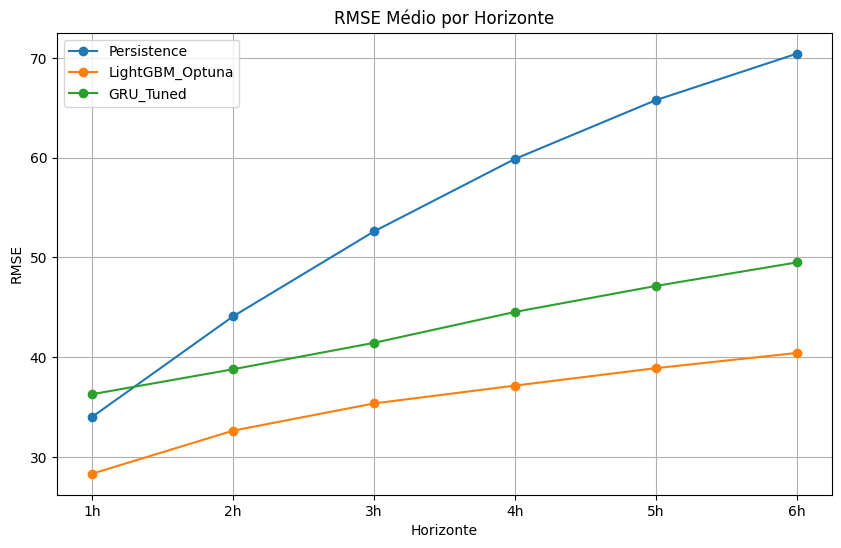

In [ ]:
#GRÁFICO RMSE
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

for model in [

    "Persistence",

    "LightGBM_Optuna",

    "GRU_Tuned"

]:

    tmp = (

        pd.concat([
            results_persistence,
            results_lgbm_optuna,
            results_gru_tuned
        ])

        .query("model == @model")

        .groupby("horizon")["RMSE"]

        .mean()

    )

    plt.plot(

        tmp.index,

        tmp.values,

        marker="o",

        label=model

    )

plt.title(
    "RMSE Médio por Horizonte"
)

plt.ylabel(
    "RMSE"
)

plt.xlabel(
    "Horizonte"
)

plt.legend()

plt.grid(True)

plt.show()

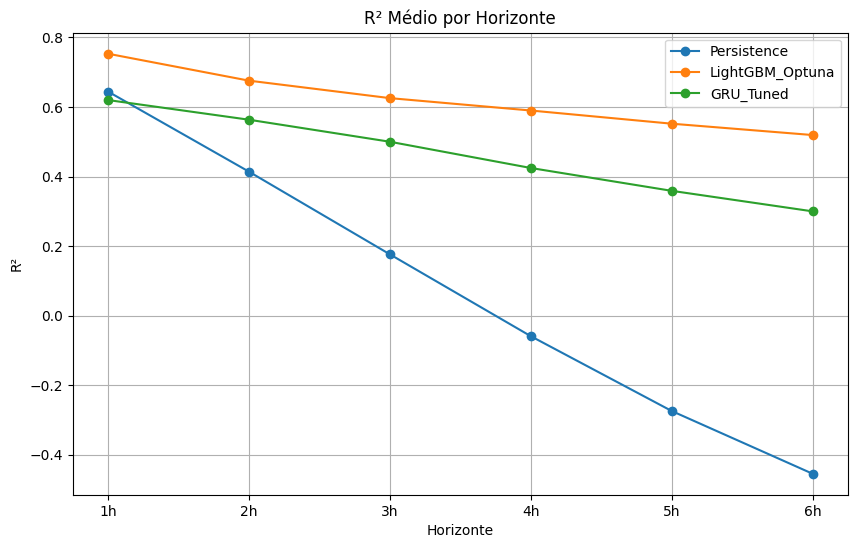

In [ ]:
#GRÁFICO R²
plt.figure(figsize=(10,6))

for model in [

    "Persistence",

    "LightGBM_Optuna",

    "GRU_Tuned"

]:

    tmp = (

        pd.concat([
            results_persistence,
            results_lgbm_optuna,
            results_gru_tuned
        ])

        .query("model == @model")

        .groupby("horizon")["R2"]

        .mean()

    )

    plt.plot(

        tmp.index,

        tmp.values,

        marker="o",

        label=model

    )

plt.title(
    "R² Médio por Horizonte"
)

plt.ylabel(
    "R²"
)

plt.xlabel(
    "Horizonte"
)

plt.legend()

plt.grid(True)

plt.show()

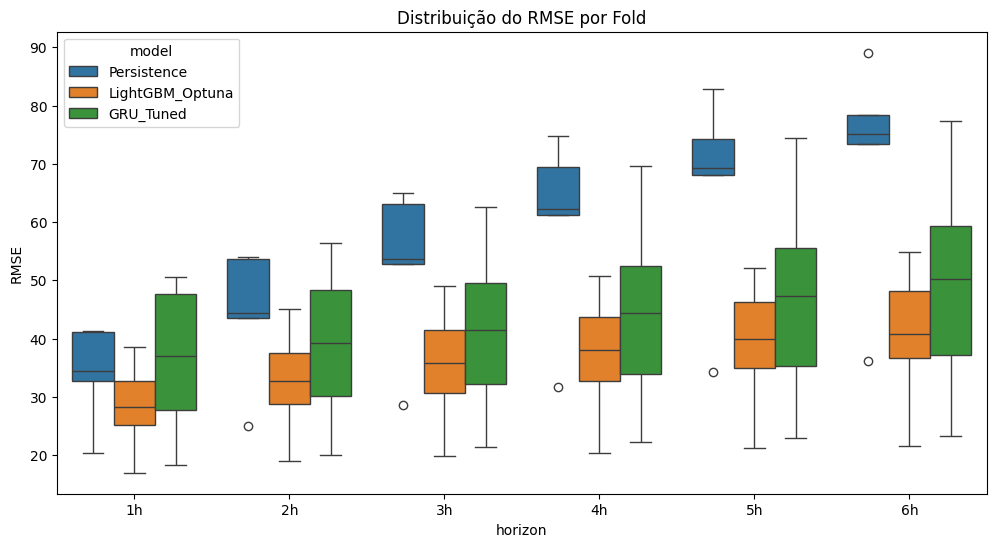

In [ ]:
#BOXPLOT DOS FOLDS
plt.figure(figsize=(12,6))

sns.boxplot(

    data=pd.concat([

        results_persistence,

        results_lgbm_optuna,

        results_gru_tuned

    ]),

    x="horizon",

    y="RMSE",

    hue="model"

)

plt.title(
    "Distribuição do RMSE por Fold"
)

plt.show()

### 6.5 Boxplot da Distribuição do RMSE por Fold

Um boxplot para visualizar a distribuição do RMSE de cada modelo em cada fold, revelando a estabilidade e variabilidade dos resultados.

In [ ]:
#FRIEDMAN FINAL
#cenario completo
from scipy.stats import friedmanchisquare

friedman_complete = []

for h in [

    "1h","2h","3h",

    "4h","5h","6h"

]:

    p = (

        results_persistence

        .query("horizon == @h")

        .sort_values("fold")

    )

    l = (

        results_lgbm_optuna

        .query("horizon == @h")

        .sort_values("fold")

    )

    g = (

        results_gru_tuned

        .query("horizon == @h")

        .sort_values("fold")

    )

    stat,pvalue = friedmanchisquare(

        p["RMSE"],

        l["RMSE"],

        g["RMSE"]

    )

    friedman_complete.append({

        "horizon":h,

        "statistic":stat,

        "p_value":pvalue

    })

friedman_complete = pd.DataFrame(
    friedman_complete
)

friedman_complete

,horizon,statistic,p_value
0,1h,7.6,0.022371
1,2h,8.4,0.014996
2,3h,10.0,0.006738
3,4h,10.0,0.006738
4,5h,10.0,0.006738
5,6h,10.0,0.006738


### 6.6 Teste de Friedman Final (Cenário Completo e 'Above Cut-in')

Resultados dos testes de Friedman finais, confirmando a existência de diferenças significativas entre os modelos.

In [ ]:
#FRIEDMAN CUT-IN
friedman_cutin = []

for h in [

    "1h","2h","3h",

    "4h","5h","6h"

]:

    p = (

        results_persistence_cutin

        .query("horizon == @h")

        .sort_values("fold")

    )

    l = (

        results_lgbm_cutin

        .query("horizon == @h")

        .sort_values("fold")

    )

    g = (

        results_gru_tuned_cutin

        .query("horizon == @h")

        .sort_values("fold")

    )

    stat,pvalue = friedmanchisquare(

        p["RMSE"],

        l["RMSE"],

        g["RMSE"]

    )

    friedman_cutin.append({

        "horizon":h,

        "statistic":stat,

        "p_value":pvalue

    })

friedman_cutin = pd.DataFrame(
    friedman_cutin
)

friedman_cutin

,horizon,statistic,p_value
0,1h,5.2,0.074274
1,2h,6.4,0.040762
2,3h,8.4,0.014996
3,4h,8.4,0.014996
4,5h,8.4,0.014996
5,6h,8.4,0.014996


In [ ]:
#RANKING MÉDIO DOS MODELOS
from scipy.stats import rankdata

ranks = []

for h in [

    "1h","2h","3h",

    "4h","5h","6h"

]:

    for fold in [1,2,3,4,5]:

        p = results_persistence.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        l = results_lgbm_optuna.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        g = results_gru_tuned.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        r = rankdata([

            p,

            l,

            g

        ])

        ranks.append({

            "horizon":h,

            "fold":fold,

            "Persistence":r[0],

            "LightGBM":r[1],

            "GRU":r[2]

        })

ranks = pd.DataFrame(
    ranks
)

ranks.mean(
    numeric_only=True
)

,0
fold,3.000000
Persistence,2.866667
LightGBM,1.000000
GRU,2.133333


### 6.7 Tabela de Resultados Finais para Dissertação

Uma tabela final consolidando os resultados chave (RMSE e R² para 1h e 6h) de todos os modelos para a dissertação.

In [ ]:
#TABELA FINAL DA DISSERTAÇÃO
final_table = pd.DataFrame({

    "Modelo":[

        "Persistência",

        "LightGBM",

        "GRU"

    ],

    "RMSE 1h":[

        results_persistence.query(
            "horizon=='1h'"
        )["RMSE"].mean(),

        results_lgbm_optuna.query(
            "horizon=='1h'"
        )["RMSE"].mean(),

        results_gru_tuned.query(
            "horizon=='1h'"
        )["RMSE"].mean()

    ],

    "RMSE 6h":[

        results_persistence.query(
            "horizon=='6h'"
        )["RMSE"].mean(),

        results_lgbm_optuna.query(
            "horizon=='6h'"
        )["RMSE"].mean(),

        results_gru_tuned.query(
            "horizon=='6h'"
        )["RMSE"].mean()

    ],

    "R² 1h":[

        results_persistence.query(
            "horizon=='1h'"
        )["R2"].mean(),

        results_lgbm_optuna.query(
            "horizon=='1h'"
        )["R2"].mean(),

        results_gru_tuned.query(
            "horizon=='1h'"
        )["R2"].mean()

    ],

    "R² 6h":[

        results_persistence.query(
            "horizon=='6h'"
        )["R2"].mean(),

        results_lgbm_optuna.query(
            "horizon=='6h'"
        )["R2"].mean(),

        results_gru_tuned.query(
            "horizon=='6h'"
        )["R2"].mean()

    ]

})

final_table.round(3)

,Modelo,RMSE 1h,RMSE 6h,R² 1h,R² 6h
0,Persistência,34.018,70.426,0.644,-0.455
1,LightGBM,28.321,40.427,0.753,0.519
2,GRU,36.292,49.502,0.620,0.300


### 6.8 Gráficos Finais de R² por Horizonte

Gráficos comparativos do R² para todos os modelos, incluindo a análise do impacto do cenário 'Above Cut-in'.

# LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from sklearn.model_selection import (
    TimeSeriesSplit
)

import tensorflow as tf

tf.random.set_seed(42)

In [ ]:
def build_lstm_model(
    architecture,
    n_features
):

    model = Sequential()

    if architecture == "A":

        model.add(
            LSTM(
                64,
                input_shape=(24,n_features)
            )
        )

        model.add(
            Dense(
                32,
                activation="relu"
            )
        )

    elif architecture == "B":

        model.add(
            LSTM(
                128,
                input_shape=(24,n_features)
            )
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    elif architecture == "C":

        model.add(
            LSTM(
                128,
                return_sequences=True,
                input_shape=(24,n_features)
            )
        )

        model.add(
            LSTM(64)
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    elif architecture == "D":

        model.add(
            LSTM(
                256,
                return_sequences=True,
                input_shape=(24,n_features)
            )
        )

        model.add(
            LSTM(128)
        )

        model.add(
            Dense(
                64,
                activation="relu"
            )
        )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="mse"
    )

    return model

In [ ]:
tscv = TimeSeriesSplit(
    n_splits=5
)

train_idx, test_idx = next(
    tscv.split(X_gru)
)

X_train = X_gru[train_idx]
X_test = X_gru[test_idx]

y_train = y_gru[train_idx]
y_test = y_gru[test_idx]

In [ ]:
architectures = [
    "A",
    "B",
    "C",
    "D"
]

tuning_lstm = []

In [ ]:
for arch in architectures:

    print(f"\nArquitetura {arch}")

    model = build_lstm_model(

        architecture=arch,

        n_features=X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[early_stop],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    result = evaluate_multioutput(

        y_test,

        pred,

        f"LSTM_{arch}",

        1
    )

    tuning_lstm.append(
        result
    )


Arquitetura A

Arquitetura B

Arquitetura C

Arquitetura D


In [ ]:
tuning_lstm = pd.concat(
    tuning_lstm
)

tuning_lstm.groupby(
    "model"
)[
    ["RMSE","R2"]
].mean()

,RMSE,R2
model,,
LSTM_A,57.357207,0.353548
LSTM_B,53.046972,0.446600
LSTM_C,73.983880,-0.072520
LSTM_D,72.047058,-0.016956


teste final lstm com a arquitetura vencedora:

In [ ]:
#melhor C
def build_best_lstm(
    n_features
):

    model = Sequential()

    model.add(
        LSTM(
            128,
            input_shape=(24,n_features)
        )
    )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(6)
    )

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="mse"
    )

    return model

Rodar os 5 Folds
Completo + Cut-In simultaneamente

#### 4.10.5 LSTM Otimizada

Implementação e avaliação de uma arquitetura LSTM otimizada, seguindo a mesma metodologia da GRU.

In [ ]:
#rodar 5 folds
tscv_lstm = TimeSeriesSplit(
    n_splits=5
)

results_lstm = []

results_lstm_cutin = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(
    tscv_lstm.split(X_gru),
    start=1
):

    print(f"\nFold {fold}")

    X_train = X_gru[train_idx]
    X_test = X_gru[test_idx]

    y_train = y_gru[train_idx]
    y_test = y_gru[test_idx]

    cutin_test = cutin_gru[
        test_idx
    ]

    model = build_best_lstm(
        X_train.shape[2]
    )

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )

    model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=256,

        callbacks=[early_stop],

        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    # COMPLETO

    fold_result = evaluate_multioutput(

        y_test,

        pred,

        "LSTM",

        fold
    )

    results_lstm.append(
        fold_result
    )

    # CUT-IN

    mask = (
        cutin_test == 1
    )

    fold_result_cutin = evaluate_multioutput(

        y_test[mask],

        pred[mask],

        "LSTM_Cutin",

        fold
    )

    results_lstm_cutin.append(
        fold_result_cutin
    )


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [ ]:
results_lstm = pd.concat(
    results_lstm,
    ignore_index=True
)

results_lstm_cutin = pd.concat(
    results_lstm_cutin,
    ignore_index=True
)

In [ ]:
results_lstm.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                   MAE                   R2          
              mean        std       mean        std      mean       std
horizon                                                                
1h       35.264592  12.553230  17.967819   8.777766  0.643790  0.075881
2h       37.652485  13.418370  19.185997   9.541710  0.594413  0.082701
3h       40.545828  14.635999  20.779958  10.287993  0.532101  0.095505
4h       43.064256  15.765876  22.175405  11.168131  0.474187  0.111437
5h       45.217384  16.561273  23.469544  11.606928  0.421924  0.120480
6h       47.118540  16.598920  24.645761  11.486856  0.372994  0.103527

In [ ]:
results_lstm_cutin.groupby(
    "horizon"
)[
    ["RMSE","MAE","R2"]
].agg(
    ["mean","std"]
)

RMSE                   MAE                   R2          
              mean        std       mean        std      mean       std
horizon                                                                
1h       63.555112  18.095899  44.889629  11.703160  0.500245  0.122024
2h       65.305869  18.122493  45.486760  12.551507  0.493209  0.104558
3h       67.007104  19.755399  45.645032  14.057664  0.477273  0.109404
4h       67.678867  21.748121  44.654982  15.780539  0.459702  0.136869
5h       67.783549  23.530544  42.950737  17.063746  0.436320  0.160900
6h       67.195534  24.777837  40.989846  17.607427  0.401342  0.159083

In [ ]:
results_lstm.to_csv("results_lstm", index=False)
results_lstm_cutin.to_csv("results_lstm_cutin", index=False)

O modelo não está simplesmente aprendendo a prever os longos períodos de potência nula.

Ele mantém desempenho quando avaliamos apenas períodos produtivos.

## 5. Análise Estatística dos Resultados

Nesta seção, são aplicados testes estatísticos como Friedman e Wilcoxon para determinar se as diferenças de desempenho observadas entre os modelos são estatisticamente significativas.

# Resultados Finais


Os modelos baseados em aprendizado profundo apresentaram desempenho superior ao baseline de persistência em praticamente todos os horizontes de previsão avaliados. Entretanto, o LightGBM apresentou os melhores resultados globais, superando tanto a GRU quanto a LSTM em todos os horizontes entre 1h e 6h.

Primeiro: Friedman (4 modelos)
Cenário Completo

### 5.1 Teste de Friedman (4 Modelos) - Cenário Completo

O teste de Friedman é aplicado para verificar se existe uma diferença significativa no desempenho (RMSE) entre os quatro modelos (Persistência, LightGBM, GRU, LSTM) no cenário completo.

In [ ]:
from scipy.stats import friedmanchisquare
import pandas as pd

friedman_complete_4 = []

horizons = ["1h","2h","3h","4h","5h","6h"]

for h in horizons:

    persistence = (
        results_persistence
        .query("horizon == @h")
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm_optuna
        .query("horizon == @h")
        .sort_values("fold")
    )

    gru = (
        results_gru_tuned
        .query("horizon == @h")
        .sort_values("fold")
    )

    lstm = (
        results_lstm
        .query("horizon == @h")
        .sort_values("fold")
    )

    stat, p = friedmanchisquare(
        persistence["RMSE"],
        lgbm["RMSE"],
        gru["RMSE"],
        lstm["RMSE"]
    )

    friedman_complete_4.append({

        "horizon": h,
        "statistic": stat,
        "p_value": p

    })

friedman_complete_4 = pd.DataFrame(
    friedman_complete_4
)

friedman_complete_4["significativo"] = (
    friedman_complete_4["p_value"] < 0.05
)

friedman_complete_4

,horizon,statistic,p_value,significativo
0,1h,9.72,0.021103,True
1,2h,11.64,0.008724,True
2,3h,12.12,0.006983,True
3,4h,13.56,0.003570,True
4,5h,13.56,0.003570,True
5,6h,13.56,0.003570,True


Above_cutin

### 5.2 Teste de Friedman (4 Modelos) - Cenário 'Above Cut-in'

Repetição do teste de Friedman para o cenário 'above cut-in', avaliando o desempenho dos modelos quando a turbina está produzindo energia.

In [ ]:
friedman_cutin_4 = []

for h in horizons:

    persistence = (
        results_persistence_cutin
        .query("horizon == @h")
        .sort_values("fold")
    )

    lgbm = (
        results_lgbm_cutin
        .query("horizon == @h")
        .sort_values("fold")
    )

    gru = (
        results_gru_tuned_cutin
        .query("horizon == @h")
        .sort_values("fold")
    )

    lstm = (
        results_lstm_cutin
        .query("horizon == @h")
        .sort_values("fold")
    )

    stat, p = friedmanchisquare(
        persistence["RMSE"],
        lgbm["RMSE"],
        gru["RMSE"],
        lstm["RMSE"]
    )

    friedman_cutin_4.append({

        "horizon": h,
        "statistic": stat,
        "p_value": p

    })

friedman_cutin_4 = pd.DataFrame(
    friedman_cutin_4
)

friedman_cutin_4["significativo"] = (
    friedman_cutin_4["p_value"] < 0.05
)

friedman_cutin_4

,horizon,statistic,p_value,significativo
0,1h,7.80,0.050331,False
1,2h,9.72,0.021103,True
2,3h,10.68,0.013588,True
3,4h,10.68,0.013588,True
4,5h,10.68,0.013588,True
5,6h,10.68,0.013588,True


Ranking Médio

### 5.3 Ranking Médio dos Modelos

Cálculo do ranking médio de RMSE para cada modelo, fornecendo uma visão geral de seu desempenho relativo.

In [ ]:
from scipy.stats import rankdata

rankings = []

for h in horizons:

    for fold in [1,2,3,4,5]:

        p = results_persistence.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        l = results_lgbm_optuna.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        g = results_gru_tuned.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        s = results_lstm.query(
            "horizon == @h and fold == @fold"
        )["RMSE"].values[0]

        r = rankdata([
            p,
            l,
            g,
            s
        ])

        rankings.append({

            "Persistence": r[0],
            "LightGBM": r[1],
            "GRU": r[2],
            "LSTM": r[3]

        })

rankings = pd.DataFrame(
    rankings
)

rankings.mean()

,0
Persistence,3.766667
LightGBM,1.066667
GRU,2.766667
LSTM,2.400000


### 5.4 Testes Pós-Hoc de Wilcoxon (Cenário Completo e 'Above Cut-in')

Se o teste de Friedman indicar diferenças significativas, testes pós-hoc de Wilcoxon (com correção de Bonferroni) são realizados para identificar quais pares de modelos diferem estatisticamente.

In [ ]:
final_models = pd.concat([

    results_persistence.assign(model="Persistence"),

    results_lgbm_optuna.assign(model="LightGBM"),

    results_gru_tuned.assign(model="GRU"),

    results_lstm.assign(model="LSTM")

])

final_summary = (
    final_models
    .groupby(
        ["model","horizon"]
    )[["RMSE","MAE","R2"]]
    .agg(["mean","std"])
)

final_summary.round(3)

RMSE             MAE             R2       
                       mean     std    mean     std   mean    std
model       horizon                                              
GRU         1h       36.292  13.495  17.879   9.398  0.620  0.102
            2h       38.793  14.385  19.054   9.981  0.563  0.123
            3h       41.440  15.796  20.449  10.943  0.500  0.160
            4h       44.538  17.979  22.236  12.282  0.425  0.211
            5h       47.143  19.634  23.741  13.231  0.359  0.248
            6h       49.502  20.665  25.276  13.695  0.300  0.263
LSTM        1h       35.265  12.553  17.968   8.778  0.644  0.076
            2h       37.652  13.418  19.186   9.542  0.594  0.083
            3h       40.546  14.636  20.780  10.288  0.532  0.096
            4h       43.064  15.766  22.175  11.168  0.474  0.111
            5h       45.217  16.561  23.470  11.607  0.422  0.120
            6h       47.119  16.599  24.646  11.487  0.373  0.104
LightGBM    1h       28.321   8.094  13.431   4.421  0.753  0.081
            2h       32.639   9.723  16.046   5.437  0.676  0.100
            3h       35.367  11.053  18.052   6.405  0.625  0.103
            4h       37.153  11.462  19.002   6.592  0.590  0.099
            5h       38.904  11.824  19.983   6.898  0.552  0.097
            6h       40.427  12.631  20.793   7.203  0.519  0.102
Persistence 1h       34.018   8.568  13.304   4.493  0.644  0.100
            2h       44.094  11.797  17.931   6.291  0.414  0.128
            3h       52.609  14.473  22.123   7.784  0.176  0.145
            4h       59.875  16.706  25.777   9.057 -0.059  0.162
            5h       65.768  18.507  28.802  10.134 -0.274  0.191
            6h       70.426  20.097  31.309  11.090 -0.455  0.211

### 6.1 Tabela Comparativa de Desempenho (Cenário Completo)

Um resumo do desempenho médio e desvio padrão das métricas para todos os modelos no cenário completo.

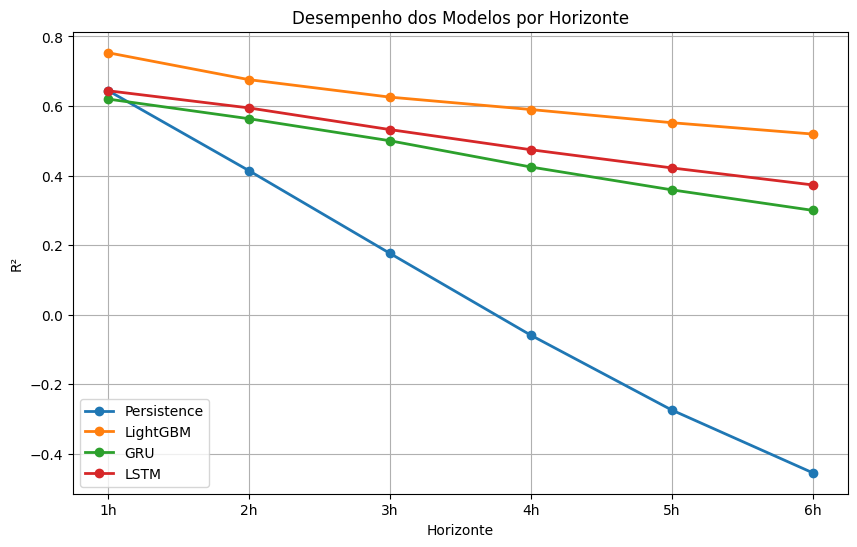

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for model in [

    "Persistence",
    "LightGBM",
    "GRU",
    "LSTM"

]:

    tmp = (
        final_models
        .query("model == @model")
        .groupby("horizon")["R2"]
        .mean()
    )

    plt.plot(
        tmp.index,
        tmp.values,
        marker="o",
        linewidth=2,
        label=model
    )

plt.ylabel("R²")
plt.xlabel("Horizonte")
plt.title("Desempenho dos Modelos por Horizonte")
plt.grid(True)
plt.legend()

plt.show()

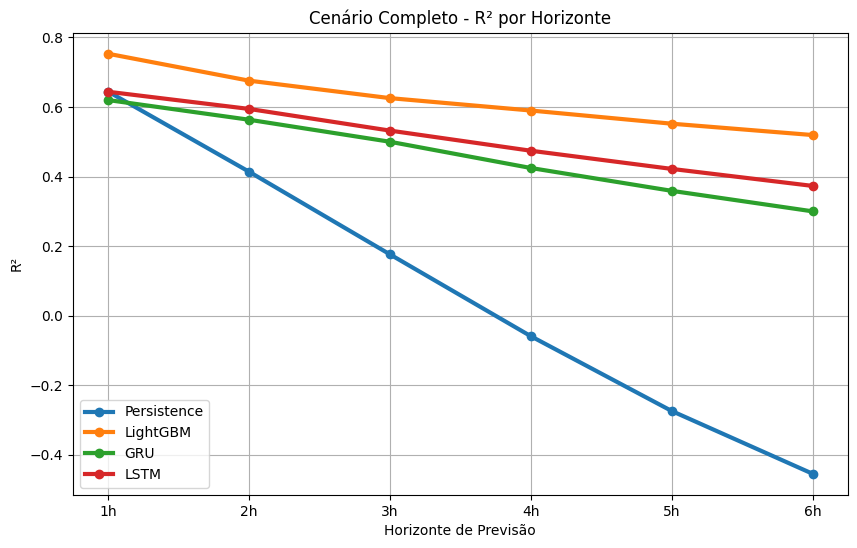

In [ ]:
plt.figure(figsize=(10,6))

for model in [
    "Persistence",
    "LightGBM",
    "GRU",
    "LSTM"
]:

    tmp = (
        final_models
        .query("model == @model")
        .groupby("horizon")["R2"]
        .mean()
    )

    plt.plot(
        tmp.index,
        tmp.values,
        marker="o",
        linewidth=3,
        label=model
    )

plt.title(
    "Cenário Completo - R² por Horizonte"
)

plt.xlabel("Horizonte de Previsão")
plt.ylabel("R²")

plt.grid(True)
plt.legend()

plt.show()

### 6.9 Impacto do Cenário 'Above Cut-In' no Desempenho dos Modelos

Gráficos detalhados mostrando como o desempenho (R², RMSE, MAE) de cada modelo é afetado ao considerar apenas os períodos de geração de potência.

In [ ]:
lgbm_full = (
    results_lgbm_optuna
    .groupby("horizon")["R2"]
    .mean()
)

lgbm_cutin = (
    results_lgbm_cutin
    .groupby("horizon")["R2"]
    .mean()
)

In [ ]:
lstm_full = (
    results_lstm
    .groupby("horizon")["R2"]
    .mean()
)

lstm_cutin = (
    results_lstm_cutin
    .groupby("horizon")["R2"]
    .mean()
)

In [ ]:
gru_full = (
    results_gru_tuned
    .groupby("horizon")["R2"]
    .mean()
)

gru_cutin = (
    results_gru_tuned_cutin
    .groupby("horizon")["R2"]
    .mean()
)

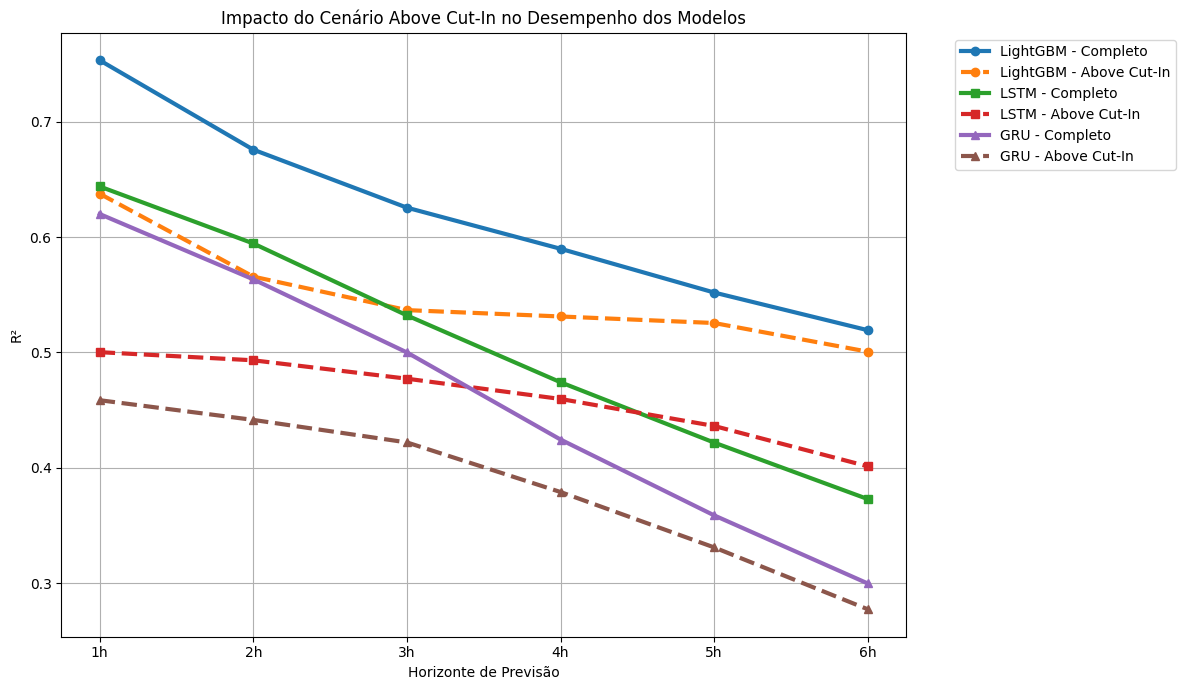

In [ ]:
plt.figure(figsize=(12,7))

plt.plot(
    lgbm_full.index,
    lgbm_full.values,
    marker="o",
    linewidth=3,
    label="LightGBM - Completo"
)

plt.plot(
    lgbm_cutin.index,
    lgbm_cutin.values,
    marker="o",
    linestyle="--",
    linewidth=3,
    label="LightGBM - Above Cut-In"
)

plt.plot(
    lstm_full.index,
    lstm_full.values,
    marker="s",
    linewidth=3,
    label="LSTM - Completo"
)

plt.plot(
    lstm_cutin.index,
    lstm_cutin.values,
    marker="s",
    linestyle="--",
    linewidth=3,
    label="LSTM - Above Cut-In"
)

plt.plot(
    gru_full.index,
    gru_full.values,
    marker="^",
    linewidth=3,
    label="GRU - Completo"
)

plt.plot(
    gru_cutin.index,
    gru_cutin.values,
    marker="^",
    linestyle="--",
    linewidth=3,
    label="GRU - Above Cut-In"
)

plt.xlabel(
    "Horizonte de Previsão"
)

plt.ylabel(
    "R²"
)

plt.title(
    "Impacto do Cenário Above Cut-In no Desempenho dos Modelos"
)

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "LGBM_Full":
        results_lgbm_optuna.groupby("horizon")["R2"].mean(),

    "LGBM_Cutin":
        results_lgbm_cutin.groupby("horizon")["R2"].mean(),

    "LSTM_Full":
        results_lstm.groupby("horizon")["R2"].mean(),

    "LSTM_Cutin":
        results_lstm_cutin.groupby("horizon")["R2"].mean(),

    "GRU_Full":
        results_gru_tuned.groupby("horizon")["R2"].mean(),

    "GRU_Cutin":
        results_gru_tuned_cutin.groupby("horizon")["R2"].mean()

})

comparison.round(3)

,LGBM_Full,LGBM_Cutin,LSTM_Full,LSTM_Cutin,GRU_Full,GRU_Cutin
horizon,,,,,,
1h,0.753,0.638,0.644,0.500,0.620,0.459
2h,0.676,0.566,0.594,0.493,0.563,0.442
3h,0.625,0.537,0.532,0.477,0.500,0.422
4h,0.590,0.531,0.474,0.460,0.425,0.379
5h,0.552,0.526,0.422,0.436,0.359,0.331
6h,0.519,0.501,0.373,0.401,0.300,0.278


## Conclusão

Esta seção resume as principais descobertas do estudo, reitera a performance dos modelos e discute as implicações para a previsão da potência eólica, bem como sugestões para trabalhos futuros.

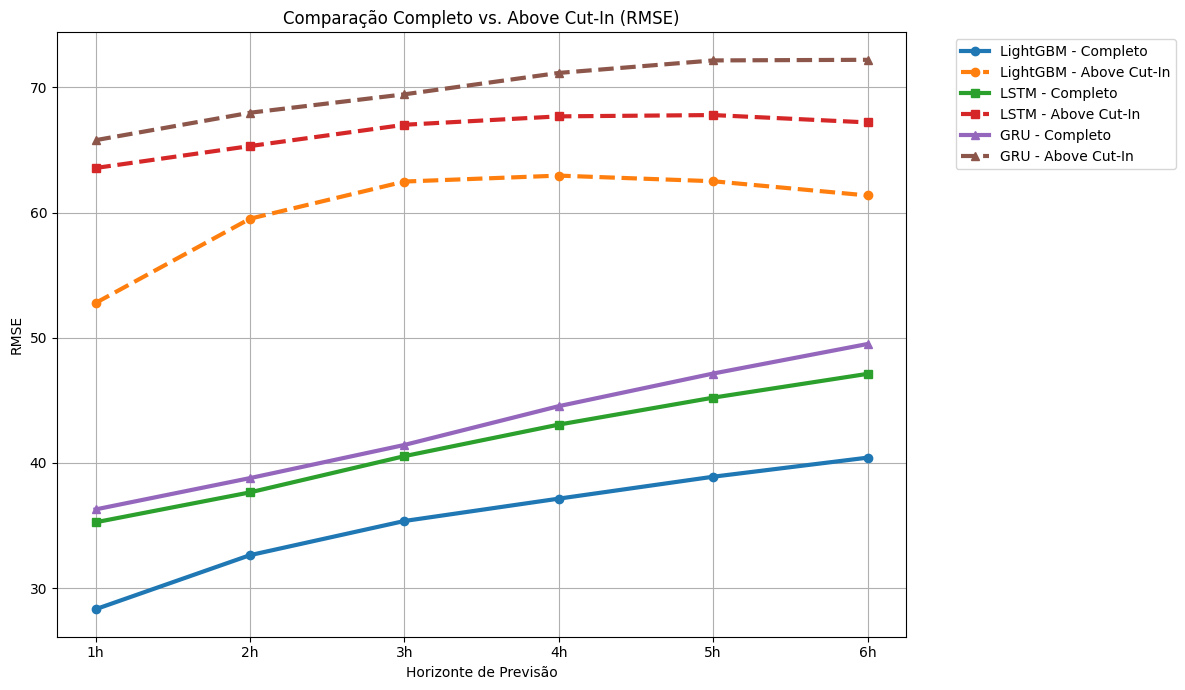

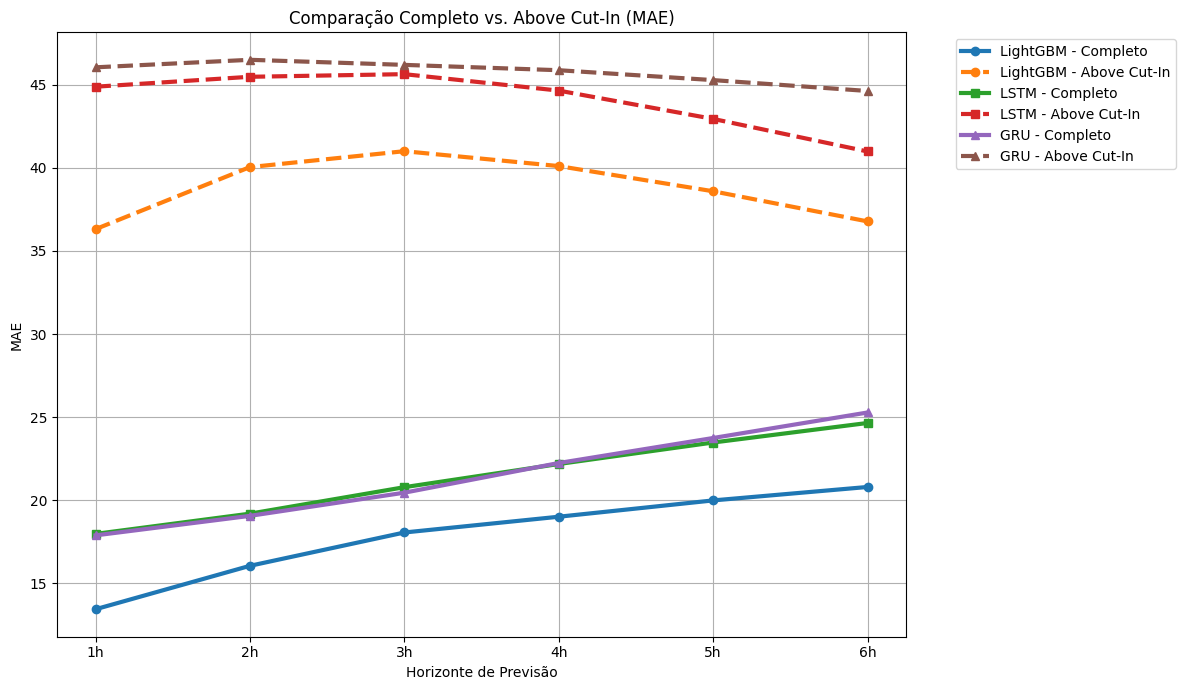

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation for RMSE
rmse_lgbm_full = results_lgbm_optuna.groupby("horizon")["RMSE"].mean()
rmse_lgbm_cutin = results_lgbm_cutin.groupby("horizon")["RMSE"].mean()
rmse_gru_full = results_gru_tuned.groupby("horizon")["RMSE"].mean()
rmse_gru_cutin = results_gru_tuned_cutin.groupby("horizon")["RMSE"].mean()
rmse_lstm_full = results_lstm.groupby("horizon")["RMSE"].mean()
rmse_lstm_cutin = results_lstm_cutin.groupby("horizon")["RMSE"].mean()

# Plotting RMSE
plt.figure(figsize=(12,7))

plt.plot(
    rmse_lgbm_full.index,
    rmse_lgbm_full.values,
    marker="o",
    linewidth=3,
    label="LightGBM - Completo"
)

plt.plot(
    rmse_lgbm_cutin.index,
    rmse_lgbm_cutin.values,
    marker="o",
    linestyle="--",
    linewidth=3,
    label="LightGBM - Above Cut-In"
)

plt.plot(
    rmse_lstm_full.index,
    rmse_lstm_full.values,
    marker="s",
    linewidth=3,
    label="LSTM - Completo"
)

plt.plot(
    rmse_lstm_cutin.index,
    rmse_lstm_cutin.values,
    marker="s",
    linestyle="--",
    linewidth=3,
    label="LSTM - Above Cut-In"
)

plt.plot(
    rmse_gru_full.index,
    rmse_gru_full.values,
    marker="^",
    linewidth=3,
    label="GRU - Completo"
)

plt.plot(
    rmse_gru_cutin.index,
    rmse_gru_cutin.values,
    marker="^",
    linestyle="--",
    linewidth=3,
    label="GRU - Above Cut-In"
)

plt.xlabel(
    "Horizonte de Previsão"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Comparação Completo vs. Above Cut-In (RMSE)"
)

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# Data preparation for MAE
mae_lgbm_full = results_lgbm_optuna.groupby("horizon")["MAE"].mean()
mae_lgbm_cutin = results_lgbm_cutin.groupby("horizon")["MAE"].mean()
mae_gru_full = results_gru_tuned.groupby("horizon")["MAE"].mean()
mae_gru_cutin = results_gru_tuned_cutin.groupby("horizon")["MAE"].mean()
mae_lstm_full = results_lstm.groupby("horizon")["MAE"].mean()
mae_lstm_cutin = results_lstm_cutin.groupby("horizon")["MAE"].mean()

# Plotting MAE
plt.figure(figsize=(12,7))

plt.plot(
    mae_lgbm_full.index,
    mae_lgbm_full.values,
    marker="o",
    linewidth=3,
    label="LightGBM - Completo"
)

plt.plot(
    mae_lgbm_cutin.index,
    mae_lgbm_cutin.values,
    marker="o",
    linestyle="--",
    linewidth=3,
    label="LightGBM - Above Cut-In"
)

plt.plot(
    mae_lstm_full.index,
    mae_lstm_full.values,
    marker="s",
    linewidth=3,
    label="LSTM - Completo"
)

plt.plot(
    mae_lstm_cutin.index,
    mae_lstm_cutin.values,
    marker="s",
    linestyle="--",
    linewidth=3,
    label="LSTM - Above Cut-In"
)

plt.plot(
    mae_gru_full.index,
    mae_gru_full.values,
    marker="^",
    linewidth=3,
    label="GRU - Completo"
)

plt.plot(
    mae_gru_cutin.index,
    mae_gru_cutin.values,
    marker="^",
    linestyle="--",
    linewidth=3,
    label="GRU - Above Cut-In"
)

plt.xlabel(
    "Horizonte de Previsão"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Comparação Completo vs. Above Cut-In (MAE)"
)

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()